**Université Technique de Sofia - Faculté Francophone**

**MÉMOIRE DE MASTER**

**Auteure :** Alexandra Alexandrova  
**Directeur :** Prof. D. Ditchev

> *This notebook provides an analysis of popular methods for automatic detection of fake news.*

> *Ce notebook propose une analyse des méthodes couramment utilisées pour la détection automatique des fausses informations.*

In [204]:
# CELL 1 - configuration
#===========================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import re, string, os, time, json, warnings
from collections import Counter
from pathlib import Path
import joblib

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
for _pkg in ('stopwords','wordnet','punkt','omw-1.4'):
    nltk.download(_pkg, quiet=True)

from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.feature_selection import chi2
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score,
)
from scipy.sparse import vstack as sp_vstack

warnings.filterwarnings('ignore')

try:
    from wordcloud import WordCloud
    WORDCLOUD_AVAILABLE = True
except ImportError:
    WORDCLOUD_AVAILABLE = False

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

SAMPLE_VEC_TRAIN = 8_000
SAMPLE_VEC_TEST  = 2_000

# Paths
DATASET_DIR  = Path('./datasets')
PREPROC_DIR  = DATASET_DIR / 'preprocessed'
SPLITS_DIR   = DATASET_DIR / 'splits'
MODELS_DIR   = Path('./models')
FIGURES_DIR  = Path('./figures')
for _d in (DATASET_DIR, PREPROC_DIR, SPLITS_DIR, MODELS_DIR, FIGURES_DIR):
    _d.mkdir(parents=True, exist_ok=True)

# Colours
COLORS = {
    'fake':     '#C0392B',
    'real':     '#1A7A4A',
    'neutral':  '#1B4F9E',
    'accent':   '#D35400',
    'purple':   '#6C3483',
    'gradient': ['#C0392B','#D35400','#D4AC0D','#1A7A4A','#1B4F9E','#6C3483'],
}

# Plot style 
plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    '#F7F9FC',
    'axes.edgecolor':    '#BBBBBB',
    'axes.labelcolor':   '#111111',
    'text.color':        '#111111',
    'xtick.color':       '#333333',
    'ytick.color':       '#333333',
    'grid.color':        '#DDDDDD',
    'grid.alpha':        0.8,
    'font.family':       'DejaVu Sans',
    'axes.titlecolor':   '#111111',
    'figure.dpi':        120,
    'legend.framealpha': 0.95,
    'legend.edgecolor':  '#CCCCCC',
    'savefig.facecolor': 'white',
})

def save_fig(name, dpi=150):
    plt.savefig(FIGURES_DIR / name, dpi=dpi, bbox_inches='tight', facecolor='white')
    print(f'Figure sauvegardée : {FIGURES_DIR / name}')

print(f' Config OK  â€”  RANDOM_STATE={RANDOM_STATE}')

 Config OK  â€”  RANDOM_STATE=42


In [205]:
# CELL 2 - data loading
#===========================================================================

def load_data(path_fake=str(DATASET_DIR/'Fake.csv'),path_true=str(DATASET_DIR/'True.csv')) :
    try:
        df_fake = pd.read_csv(path_fake)
        df_true = pd.read_csv(path_true)
    except Exception as e:
        import kagglehub
        path = kagglehub.dataset_download("clmentbisaillon/fake-and-real-news-dataset",output_dir=DATASET_DIR, force_download=True)
        df_fake = pd.read_csv('./datasets/Fake.csv')
        df_true = pd.read_csv('./datasets/True.csv')
        
    print("Path to dataset files:", DATASET_DIR)
    
    df_fake.drop(columns=['date', 'subject'],inplace=True)
    df_true.drop(columns=['date', 'subject'],inplace=True)
    df_fake['label'] = 0
    df_true['label'] = 1
    df = pd.concat([df_fake, df_true], ignore_index=True)
    df = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
    return df, df_fake, df_true

df, df_fake, df_true = load_data()
print(f"Dataset loaded: {len(df)} articles ({len(df_fake)} fake, {len(df_true)} real)")

Path to dataset files: datasets
Dataset loaded: 44898 articles (23481 fake, 21417 real)


In [206]:
# CELL 3 - data quality check and cleaning
#============================================================================
assert not df.empty
assert {'text','title','label'}.issubset(df.columns) 
assert df['label'].isin([0,1]).all() 

empty_text_count=df["text"].str.strip().eq('').sum()
empty_text_count_fake=df_fake["text"].str.strip().eq('').sum()
empty_text_count_true=df_true["text"].str.strip().eq('').sum()
print(f"{empty_text_count} empty text articles detected({empty_text_count_fake} in the fake dataset, {empty_text_count_true} in the true dataset)")

df = df[~df["text"].str.strip().eq('')].reset_index(drop=True)
df_fake = df_fake[~df_fake["text"].str.strip().eq('')].reset_index(drop=True)
df_true = df_true[~df_true["text"].str.strip().eq('')].reset_index(drop=True)
print(f"Articles after removing empty texts : {len(df):,} ")

n_dupes = df.duplicated(subset=['text']).sum()
n_dupes_fake = df_fake.duplicated(subset=['text']).sum()
n_dupes_true = df_true.duplicated(subset=['text']).sum()
print(f"{n_dupes} duplicates ({n_dupes_fake} in the fake dataset, {n_dupes_true} in the true dataset)")

df = df.drop_duplicates(subset=['text']).reset_index(drop=True)
df_fake= df_fake.drop_duplicates(subset=['text']).reset_index(drop=True)
df_true = df_true.drop_duplicates(subset=['text']).reset_index(drop=True)
print(f"Articles after deduplication : {len(df):,} ")


print(f'Total: {len(df)} | Fake: {len(df_fake)} | True: {len(df_true)}')
df.head(5)

631 empty text articles detected(630 in the fake dataset, 1 in the true dataset)
Articles after removing empty texts : 44,267 
5623 duplicates (5398 in the fake dataset, 225 in the true dataset)
Articles after deduplication : 38,644 
Total: 38644 | Fake: 17453 | True: 21191


,title,text,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",1


In [207]:
# #CELL 4  EDA visualisation 
# #===============================================
# df['text_len']       = df['text'].fillna('').apply(len)
# df['word_count']     = df['text'].fillna('').apply(lambda x: len(x.split()))
# df['title_words']    = df['title'].fillna('').apply(lambda x: len(x.split()))
# df['unique_words']   = df['text'].fillna('').apply(lambda x: len(set(x.lower().split())))
# df['lexical_richness'] = df['unique_words'] / (df['word_count'] + 1)
# df['avg_word_len']     = df['text'].fillna('').apply(lambda x: np.mean([len(w) for w in x.split()]) if x.split() else 0)
# df['sent_count']       = df['text'].fillna('').apply(lambda x: max(1, x.count('.') + x.count('!') + x.count('?')))
# df['avg_sent_len']     = df['word_count'] / df['sent_count']
# df['caps_ratio']       = df['text'].fillna('').apply(lambda x: sum(1 for c in x if c.isupper()) / max(len(x), 1))
# df['exclaim_count']    = df['text'].fillna('').apply(lambda x: x.count('!'))
# df['question_count']   = df['text'].fillna('').apply(lambda x: x.count('?'))
# df['digit_ratio']      = df['text'].fillna('').apply(lambda x: sum(c.isdigit() for c in x) / max(len(x), 1))

# print("Features textuelles calculées.")
# for feat in ['text_len','word_count','lexical_richness','avg_word_len','caps_ratio','avg_sent_len']:
#     fake_m = df[df['label']==0][feat].mean()
#     real_m = df[df['label']==1][feat].mean()
#     print(f"  {feat:<22}  FAUX={fake_m:.3f}  VRAI={real_m:.3f}  diff={abs(fake_m-real_m)/real_m*100:.1f}%")

# fig = plt.figure(figsize=(20, 16))
# fig.patch.set_facecolor('white')
# gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.35)
# PAIRS = [(0, COLORS['fake'], 'FAUX'), (1, COLORS['real'], 'VRAI')]

# # 1. Class distribution
# ax = fig.add_subplot(gs[0, 0]); ax.set_facecolor('#F7F9FC')
# counts = [len(df_fake), len(df_true)]
# bars = ax.bar(['FAUX', 'VRAI'], counts,
#             color=[COLORS['fake'], COLORS['real']], width=0.5, edgecolor='white', alpha=0.85)
# for bar, count in zip(bars, counts):
#     ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 150,
#             f'{count:,}\n({count/len(df)*100:.1f}%)',
#             ha='center', va='bottom', fontsize=10, fontweight='bold')
# ax.set_title('Distribution des classes', fontsize=12, fontweight='bold', pad=10)
# ax.set_ylabel("Nombre d'articles"); ax.set_ylim(0, max(counts)*1.3)
# ax.grid(axis='y', alpha=0.4)

# # 2. Text length
# ax = fig.add_subplot(gs[0, 1]); ax.set_facecolor('#F7F9FC')
# for lbl, col, nm in PAIRS:
#     data = df[df['label']==lbl]['text_len'].clip(0, 5500)
#     ax.hist(data, bins=60, alpha=0.45, color=col, label=nm)
#     from scipy.stats import gaussian_kde
#     kde = gaussian_kde(data, bw_method=0.15)
#     xs  = np.linspace(0, 5500, 300)
#     ax.plot(xs, kde(xs), color=col, lw=2)
#     ax.axvline(data.median(), color=col, lw=1.5, ls='--', alpha=0.8,label=f'Médiane {nm} {data.median():.0f}')
# ax.set_title('Ratio de majuscules', fontsize=12, fontweight='bold', pad=10)
# ax.set_xlabel('Caractères'); ax.set_ylabel('Articles')
# ax.legend(fontsize=7); ax.grid(alpha=0.4)

# # 3. Word count
# ax = fig.add_subplot(gs[0, 2]); ax.set_facecolor('#F7F9FC')
# for lbl, col, nm in PAIRS:
#     data = df[df['label']==lbl]['word_count'].clip(0, 1500)
#     ax.hist(data, bins=60, alpha=0.45, color=col, label=nm)
#     kde = gaussian_kde(data, bw_method=0.18)
#     xs  = np.linspace(0, 1500, 300)
#     ax.plot(xs, kde(xs), color=col, lw=2)
#     ax.axvline(data.median(), color=col, lw=1.5, ls='--', alpha=0.8)
# ax.set_title('Nombre de mots par article', fontsize=12, fontweight='bold', pad=10)
# ax.set_xlabel('Mots'); ax.set_ylabel('Articles')
# ax.legend(fontsize=8); ax.grid(alpha=0.4)

# # 4. Lexical richness
# ax = fig.add_subplot(gs[1, 0]); ax.set_facecolor('#F7F9FC')
# for lbl, col, nm in PAIRS:
#     data = df[df['label']==lbl]['lexical_richness'].clip(0, 1)
#     ax.hist(data, bins=50, alpha=0.45, color=col, label=nm)
#     ax.axvline(data.mean(), color=col, lw=2, ls='-',
#             label=f'Moy. {nm} {data.mean():.3f}')
# ax.set_title('Richesse lexicale (mots uniques / total)', fontsize=12, fontweight='bold', pad=10)
# ax.set_xlabel('Ratio'); ax.set_ylabel('Articles')
# ax.legend(fontsize=7); ax.grid(alpha=0.4)

# # 5. Capital letters ratio
# ax = fig.add_subplot(gs[1, 1]); ax.set_facecolor('#F7F9FC')
# for lbl, col, nm in PAIRS:
#     data = df[df['label']==lbl]['caps_ratio'].clip(0, 0.15)
#     ax.hist(data, bins=50, alpha=0.45, color=col, label=nm)
#     ax.axvline(data.mean(), color=col, lw=2, ls='-',
#             label=f'Moy. {nm} {data.mean():.4f}')
# ax.set_title('Ratio de majuscules', fontsize=12, fontweight='bold', pad=10)
# ax.set_xlabel('Proportion de caractères en majuscule'); ax.set_ylabel('Articles')
# ax.legend(fontsize=7); ax.grid(alpha=0.4)

# # 6. Average sentence length
# ax = fig.add_subplot(gs[1, 2]); ax.set_facecolor('#F7F9FC')
# for lbl, col, nm in PAIRS:
#     data = df[df['label']==lbl]['avg_sent_len'].clip(0, 80)
#     ax.hist(data, bins=50, alpha=0.45, color=col, label=nm)
#     ax.axvline(data.mean(), color=col, lw=2, ls='-',
#             label=f'Moy. {nm} {data.mean():.1f} mots')
# ax.set_title('Longueur moyenne des phrases (mots)', fontsize=12, fontweight='bold', pad=10)
# ax.set_xlabel('Mots par phrase'); ax.set_ylabel('Articles')
# ax.legend(fontsize=7); ax.grid(alpha=0.4)

# # 7. Punctuation evaluation- ? and !
# ax = fig.add_subplot(gs[2, 0]); ax.set_facecolor('#F7F9FC')
# punct_feats = ['exclaim_count', 'question_count']
# xlabels_p   = ['Points\nd\'exclamation (!)', 'Points\nd\'interrogation (?)']
# x = np.arange(len(punct_feats))
# for offset, (lbl, col, nm) in zip([-0.2, 0.2], PAIRS):
#     sub  = df[df['label']==lbl]
#     means = [sub[f].mean() for f in punct_feats]
#     bars  = ax.bar(x+offset, means, width=0.35, color=col, alpha=0.8,
#                 edgecolor='white', label=nm)
#     for b, m in zip(bars, means):
#         ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.05,
#                 f'{m:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
# ax.set_xticks(x); ax.set_xticklabels(xlabels_p, fontsize=9)
# ax.set_title('Ponctuation expressive', fontsize=12, fontweight='bold', pad=10)
# ax.set_ylabel('Nombre moyen par article')
# ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.4)

# save_fig('01_data_exploration.png'); 
# plt.show()

In [208]:
# # CELL 5b - data preprocessing analytics only . DO NOT RUN WITH cell 5- this will create dublicates and overfitting
# stemmer    = PorterStemmer()
#lemmatizer = WordNetLemmatizer()
# def clean_basic(text):
#     """A - Minimal: lowercase, URLs, punctuation."""
#     text = str(text).lower()
#     text = re.sub(r'https?://\S+|www\.\S+', '', text)
#     text = re.sub(r'[^a-zA-Z\s]', ' ', text)
#     return re.sub(r'\s+', ' ', text).strip()

# def clean_with_stopwords(text):
#     """B - A + NLTK stopword removal."""
#     return ' '.join(w for w in clean_basic(text).split()
#                     if w not in STOP_WORDS and len(w) > 2)

# def clean_with_stemming(text):
#     """C - B + Porter stemming."""
#     return ' '.join(stemmer.stem(w) for w in clean_with_stopwords(text).split())

# def clean_with_lemmatization(text):
#     """D - B + WordNet lemmatisation."""
#     return ' '.join(lemmatizer.lemmatize(w) for w in clean_with_stopwords(text).split())

# def clean(text):
#     """E - Full pipeline [SELECTED]: lowercase, URL/email/mention removal, Porter stem, stopwords."""
#     text = str(text).lower()
#     text = re.sub(r'https?://\S+|www\.\S+', '', text)
#     text = re.sub(r'\S+@\S+|@\w+|#', '', text)
#     text = re.sub(r'[^a-zA-Z\s]', ' ', text)
#     text = re.sub(r'\s+', ' ', text).strip()
#     return ' '.join(stemmer.stem(w) for w in text.split()
#                     if w not in STOP_WORDS and len(w) > 2)

# PREPROC_SAMPLE = 5_000
# rng_pre    = np.random.RandomState(RANDOM_STATE)
# sample_idx = rng_pre.choice(len(df), min(PREPROC_SAMPLE, len(df)), replace=False)

# print('Applying pipeline E to full corpus...')
# t0 = time.time()
# df['text_clean'] = df['text'].apply(clean)
# t_full = time.time() - t0
# print(f'  Done in {t_full:.1f}s')

# print('Applying pipelines A-D to sample for comparison...')
# pipeline_funcs = {
#     'Basique':       (clean_basic,              'text_basic'),
#     'Stop-words':    (clean_with_stopwords,     'text_stop'),
#     'Stemming':      (clean_with_stemming,      'text_stem'),
#     'Lemmatisation': (clean_with_lemmatization, 'text_lemma'),
#     'Complet':       (clean_full,               'text_full'),
# }
# sample_df = df.iloc[sample_idx].copy()
# pipeline_timings = {}
# for name, (func, col) in pipeline_funcs.items():
#     t0 = time.time()
#     sample_df[col] = sample_df['text'].apply(func)
#     pipeline_timings[name] = time.time() - t0

# pipelines = {name: (col, pipeline_timings[name]) for name, (_, col) in pipeline_funcs.items()}

# pipeline_stats = {}
# base_vocab = None
# for name, (col, dur) in pipelines.items():
#     avg_tok = sample_df[col].apply(lambda x: len(x.split())).mean()
#     vocab   = len(set(' '.join(sample_df[col]).split()))
#     if base_vocab is None:
#         base_vocab = vocab
#         reduction  = '(reference)'
#     else:
#         reduction = f'-{(1 - vocab / base_vocab) * 100:.1f}%'
#     pipeline_stats[name] = dict(col=col, dur=dur, avg_tok=avg_tok, vocab=vocab, reduction=reduction)

# strategy_funcs = [
#     ('A - Basique',        clean_basic,              'Minuscules + suppression URLs/ponctuation'),
#     ('B - Stop-words',     clean_with_stopwords,     'A + suppression 179 stopwords NLTK'),
#     ('C - Stemming',       clean_with_stemming,      'B + racinisation Porter'),
#     ('D - Lemmatisation',  clean_with_lemmatization, 'B + lemmatisation WordNet'),
#     ('E - Complet',        clean_full,               'Tout + suppression emails/mentions/hashtags'),
# ]
# examples = [
#     ('Article FAUX (politique)',    df[df['label']==0].iloc[0]),
#     ('Article VRAI (Reuters)',      df[df['label']==1].iloc[0]),
#     ('Article FAUX (sensationnel)', df[df['label']==0].iloc[5]),
# ]
# for ex_name, row in examples:
#     raw = str(row['text'])[:250]
#     print(f'\n{"-"*95}')
#     print(f'{ex_name}  [{"FAUX" if row["label"]==0 else "VRAI"}]')
#     print(f'Titre : {str(row["title"])[:85]}')
#     print(f'{"-"*95}')
#     rows = []
#     for sname, func, desc in strategy_funcs:
#         result  = func(raw)
#         tokens  = result.split()
#         preview = ' '.join(tokens[:20]) + ('...' if len(tokens) > 20 else '')
#         rows.append({'Strategie': sname, 'Description': desc,'Tokens': len(tokens), 'Apercu': preview})
#     print(pd.DataFrame(rows).to_string(index=False, max_colwidth=65))

# print(f'\n{"="*95}')
# print('IMPACT SUR LE CORPUS COMPLET')
# print(f'{"="*95}')
# print(f'{"Strategie":<22}{"Tokens moy.":>13}{"Vocab. unique":>15}{"Reduction vocab":>17}{"Temps (s)":>11}')
# print('-' * 80)
# for name, s in pipeline_stats.items():
#     print(f'{name:<22}{s["avg_tok"]:>13.0f}{s["vocab"]:>15,}{s["reduction"]:>17}{s["dur"]:>11.2f}')

# X_all = df['text_clean']

# y_all = df['label']

# X_train_raw, X_temp, y_train, y_temp, idx_train, idx_temp = train_test_split(
#     X_all, y_all, df.index,
#     test_size=0.30, random_state=RANDOM_STATE, stratify=y_all)

# X_val_raw, X_test_raw, y_val, y_test, idx_val, idx_test = train_test_split(
#     X_temp, y_temp, idx_temp,
#     test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp)

# for sname, idx_s in [('train', idx_train), ('val', idx_val), ('test', idx_test)]:
#     df.loc[idx_s, ['title', 'text', 'text_clean', 'label']].to_csv(SPLITS_DIR/f'{sname}.csv', index=True)

# with open(SPLITS_DIR / 'split_indices.json', 'w') as f:
#     json.dump({'train': list(map(int, idx_train)),
#                 'val':   list(map(int, idx_val)),
#                 'test':  list(map(int, idx_test))}, f, indent=2)

# df[['title', 'text', 'text_clean', 'label']].to_csv(
#     PREPROC_DIR / 'dataset_final_E.csv', index=False)

# save_map = {
#     'A_basique':       'text_basic',
#     'B_stopwords':     'text_stop',
#     'C_stemming':      'text_stem',
#     'D_lemmatisation': 'text_lemma',
#     'E_complet':       'text_full',
# }
# for suffix, col in save_map.items():
#     out = sample_df[['title', col, 'label']].copy()
#     out.columns = ['title', 'text_preprocessed', 'label']
#     out.to_csv(PREPROC_DIR / f'sample_{suffix}.csv', index=False)


# print(f'Splits       -> {SPLITS_DIR}')
# print(f'Preprocessed -> {PREPROC_DIR}')
# print('Pipeline E (Complet) selected for downstream steps.')

In [209]:
# # CELL 5c - visualisation
# assert set(idx_train).isdisjoint(set(idx_val)),  'LEAK train/val'
# assert set(idx_train).isdisjoint(set(idx_test)), 'LEAK train/test'
# assert set(idx_val).isdisjoint(set(idx_test)),   'LEAK val/test'
# assert len(idx_train) + len(idx_val) + len(idx_test) == len(df)

# for sname, ys in [('TRAIN', y_train), ('VAL', y_val), ('TEST', y_test)]:
#     print(f'{sname:<6}: {len(ys):>6,} articles | VRAIS={ys.mean():.3f} FAUX={1-ys.mean():.3f}')

# fig, axes = plt.subplots(2, 2, figsize=(20, 12))
# fig.patch.set_facecolor('white')

# ax = axes[0, 0]
# vocab_sizes = {n: s['vocab'] for n, s in pipeline_stats.items()}
# bars = ax.bar(vocab_sizes.keys(), vocab_sizes.values(),
#                 color=COLORS['gradient'][:5], alpha=0.85, edgecolor='white')
# for bar, val in zip(bars, vocab_sizes.values()):
#     ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
#             f'{val:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')
# ax.set_title('Taille du vocabulaire par pipeline', fontsize=12, fontweight='bold')
# ax.set_ylabel('Mots uniques'); ax.tick_params(axis='x', rotation=20); ax.grid(axis='y', alpha=0.4)

# ax = axes[0, 1]
# avg_lens = {n: s['avg_tok'] for n, s in pipeline_stats.items()}
# ax.plot(list(avg_lens.keys()), list(avg_lens.values()), 'o-',
#         color=COLORS['neutral'], linewidth=2.5, markersize=10, markeredgecolor='white')
# for i, (n, v) in enumerate(avg_lens.items()):
#     ax.annotate(f'{v:.0f}', (i, v), textcoords='offset points', xytext=(0, 10),
#                 ha='center', fontsize=9, fontweight='bold')
# ax.set_title('Tokens moyens/article', fontsize=12, fontweight='bold')
# ax.set_ylabel('Tokens moyens'); ax.tick_params(axis='x', rotation=20); ax.grid(alpha=0.4)

# ax = axes[1, 0]
# pipeline_scores = {}
# for name, (col, _) in pipelines.items():
#     pipe = Pipeline([
#         ('tfidf', TfidfVectorizer(max_features=50_000)),
#         ('clf',   LogisticRegression(max_iter=200, random_state=RANDOM_STATE, solver='liblinear'))
#     ])
#     sc = cross_val_score(pipe, sample_df[col], sample_df['label'], cv=3, scoring='f1', n_jobs=-1)
#     pipeline_scores[name] = sc.mean()
# max_sc = max(pipeline_scores.values())
# bc = [COLORS['real'] if v >= max_sc - 1e-4 else COLORS['fake'] for v in pipeline_scores.values()]
# bars = ax.bar(pipeline_scores.keys(), pipeline_scores.values(), color=bc, alpha=0.85, edgecolor='white')
# for bar, v in zip(bars, pipeline_scores.values()):
#     ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
#             f'{v:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
# ax.set_title('F1-Score par pipeline (CV=3)', fontsize=12, fontweight='bold')
# ax.set_ylabel('F1-Score'); ax.set_ylim(min(pipeline_scores.values()) - 0.01, 0.99)
# ax.tick_params(axis='x', rotation=20); ax.grid(axis='y', alpha=0.4)
# ax.legend(handles=[mpatches.Patch(color=COLORS['real'], label='Meilleur'),
#                     mpatches.Patch(color=COLORS['fake'], label='Sous-optimal')], fontsize=8)

# ax = axes[1, 1]
# _train_texts  = df.loc[idx_train, 'text_clean']
# _train_labels = df.loc[idx_train, 'label']
# tfidf_tmp  = TfidfVectorizer(max_features=20_000, min_df=5)
# X_tmp      = tfidf_tmp.fit_transform(_train_texts)
# chi2_sc, _ = chi2(X_tmp, _train_labels)
# feat_chi   = np.array(tfidf_tmp.get_feature_names_out())
# top_idx    = np.argsort(chi2_sc)[-20:]
# ax.barh(range(20), chi2_sc[top_idx], color=COLORS['accent'], alpha=0.82, edgecolor='white')
# ax.set_yticks(range(20)); ax.set_yticklabels(feat_chi[top_idx], fontsize=9)
# ax.set_title('Top 20 mots discriminants (Ï‡Â²)', fontsize=12, fontweight='bold')
# ax.set_xlabel('Score Ï‡Â²'); ax.grid(axis='x',alpha=0.4)

# fig.suptitle('ANALYSE DU PRETRAITEMENT TEXTUEL', fontsize=15, fontweight='bold', y=1.01)
# save_fig('02_preprocessing_analysis.png'); 
# plt.show()

In [210]:
# CELL 5 - preprocessing split,save
STOP_WORDS = set(stopwords.words('english'))

STOP_WORDS.update([
    'reuters', 'reuter', 'ap', 'afp', 'bbc', 'cnn', 'nbc', 'abc',
    'associated', 'press', 'reporting', 'reported', 'report', 'edited', 'editing',
]) #noise

stemmer    = PorterStemmer()

def clean(text):
    text=text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'\S+@\S+|@\w+|#', '', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return ' '.join(stemmer.stem(w) for w in text.split()
                    if w not in STOP_WORDS and len(w) > 2)
    
    
# def clean(text):
#   text=text.lower()
    # text = re.sub(r'https?://\S+|www\.\S+', '', text)
    # text = re.sub(r'\S+@\S+|@\w+|#', '', text)
    # text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    # text = re.sub(r'\s+', ' ', text).strip()
    # return ' '.join(w for w in text.split()
    #                 if w not in STOP_WORDS and len(w) > 2)

t0 = time.time()
df['text_clean'] = df['text'].apply(clean)
t_full = time.time() - t0
print(f'  Done in {t_full:.1f}s')
X_all = df['text_clean']

y_all = df['label']

X_train_raw, X_temp, y_train, y_temp, idx_train, idx_temp = train_test_split(
    X_all, y_all, df.index,
    test_size=0.30, random_state=RANDOM_STATE, stratify=y_all)

X_val_raw, X_test_raw, y_val, y_test, idx_val, idx_test = train_test_split(
    X_temp, y_temp, idx_temp,
    test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp)

for sname, idx_s in [('train', idx_train), ('val', idx_val), ('test', idx_test)]:
    df.loc[idx_s, ['title', 'text', 'text_clean', 'label']].to_csv(SPLITS_DIR/f'{sname}.csv', index=True)

with open(SPLITS_DIR / 'split_indices.json', 'w') as f:
    json.dump({'train': list(map(int, idx_train)),
                'val':   list(map(int, idx_val)),
                'test':  list(map(int, idx_test))}, f, indent=2)

df[['title', 'text', 'text_clean', 'label']].to_csv(
    PREPROC_DIR / 'dataset_preprocessed.csv', index=False)

print(f'Splits       -> {SPLITS_DIR}')
print(f'Preprocessed -> {PREPROC_DIR}')

  Done in 201.0s
Splits       -> datasets\splits
Preprocessed -> datasets\preprocessed


In [229]:
# CELL 7 - vectorization  
#==================================================================
rng    = np.random.RandomState(RANDOM_STATE)
all_tr = np.arange(len(X_train_raw))
rng.shuffle(all_tr)
idx_tr = all_tr[:SAMPLE_VEC_TRAIN]
idx_te = all_tr[SAMPLE_VEC_TRAIN:SAMPLE_VEC_TRAIN + SAMPLE_VEC_TEST]
X_tr_s, y_tr_s = X_train_raw.iloc[idx_tr], y_train.iloc[idx_tr]
X_te_s, y_te_s = X_train_raw.iloc[idx_te], y_train.iloc[idx_te]

vectorizer_configs = {
    'CountVec (unigrams)': CountVectorizer(max_features=20_000, min_df=2),
    'TF-IDF (unigrams)':   TfidfVectorizer(max_features=20_000, min_df=2),
    'TF-IDF (bigrams)':    TfidfVectorizer(max_features=20_000, ngram_range=(1,2), min_df=2),
    'TF-IDF (trigrams)':   TfidfVectorizer(max_features=20_000, ngram_range=(1,3), min_df=2),
    'TF-IDF (sublinear)':  TfidfVectorizer(max_features=20_000, sublinear_tf=True, min_df=2),
    'TF-IDF (char 3-5)':   TfidfVectorizer(max_features=15_000, analyzer='char_wb',ngram_range=(3,5), min_df=2),
}

print(f'{"Vectoriseur":<30} {"Accuracy":<10} {"F1":<10} {"Temps (s)"}')
print('-'*60)
vec_results = {}
for vname, vec in vectorizer_configs.items():
    pipe = Pipeline([('vec',vec),
                    ('clf',LogisticRegression(max_iter=200,random_state=RANDOM_STATE,solver='liblinear'))])
    t0 = time.time(); pipe.fit(X_tr_s,y_tr_s); preds = pipe.predict(X_te_s); el=time.time()-t0
    vec_results[vname] = {
        'accuracy':  accuracy_score(y_te_s,preds),
        'f1':        f1_score(y_te_s,preds,average='weighted'),
        'precision': precision_score(y_te_s,preds,average='weighted',zero_division=0),
        'recall':    recall_score(y_te_s,preds,average='weighted'),
        'time': el}
    print(f'{vname:<30} {vec_results[vname]["accuracy"]:.4f}    {vec_results[vname]["f1"]:.4f}    {el:.1f}s')

# Final vectorizer - fit on TRAIN ONLY 
vectorizer   = TfidfVectorizer(max_features=50_000, sublinear_tf=True, min_df=3, ngram_range=(1,2))
X_train_vec  = vectorizer.fit_transform(X_train_raw)
X_val_vec    = vectorizer.transform(X_val_raw)
X_test_vec   = vectorizer.transform(X_test_raw)

# Unigram/bigram balance check 
feat_names = vectorizer.get_feature_names_out()
n_uni = sum(1 for f in feat_names if ' ' not in f)
n_bi  = len(feat_names) - n_uni
print(f'Vectoriseur final” Train:{X_train_vec.shape} Val:{X_val_vec.shape} Test:{X_test_vec.shape}')
print(f'Unigrammes: {n_uni:,} ({n_uni/len(feat_names)*100:.0f}%)  Bigrammes: {n_bi:,} ({n_bi/len(feat_names)*100:.0f}%)')



Vectoriseur                    Accuracy   F1         Temps (s)
------------------------------------------------------------
CountVec (unigrams)            0.9665    0.9665    9.6s
TF-IDF (unigrams)              0.9680    0.9680    10.4s
TF-IDF (bigrams)               0.9710    0.9710    23.1s
TF-IDF (trigrams)              0.9710    0.9709    33.2s
TF-IDF (sublinear)             0.9665    0.9665    4.6s
TF-IDF (char 3-5)              0.9590    0.9590    49.3s
Vectoriseur final” Train:(27050, 50000) Val:(5797, 50000) Test:(5797, 50000)
Unigrammes: 12,529 (25%)  Bigrammes: 37,471 (75%)


Figure sauvegardée : figures\03_vectorization_comparison.png


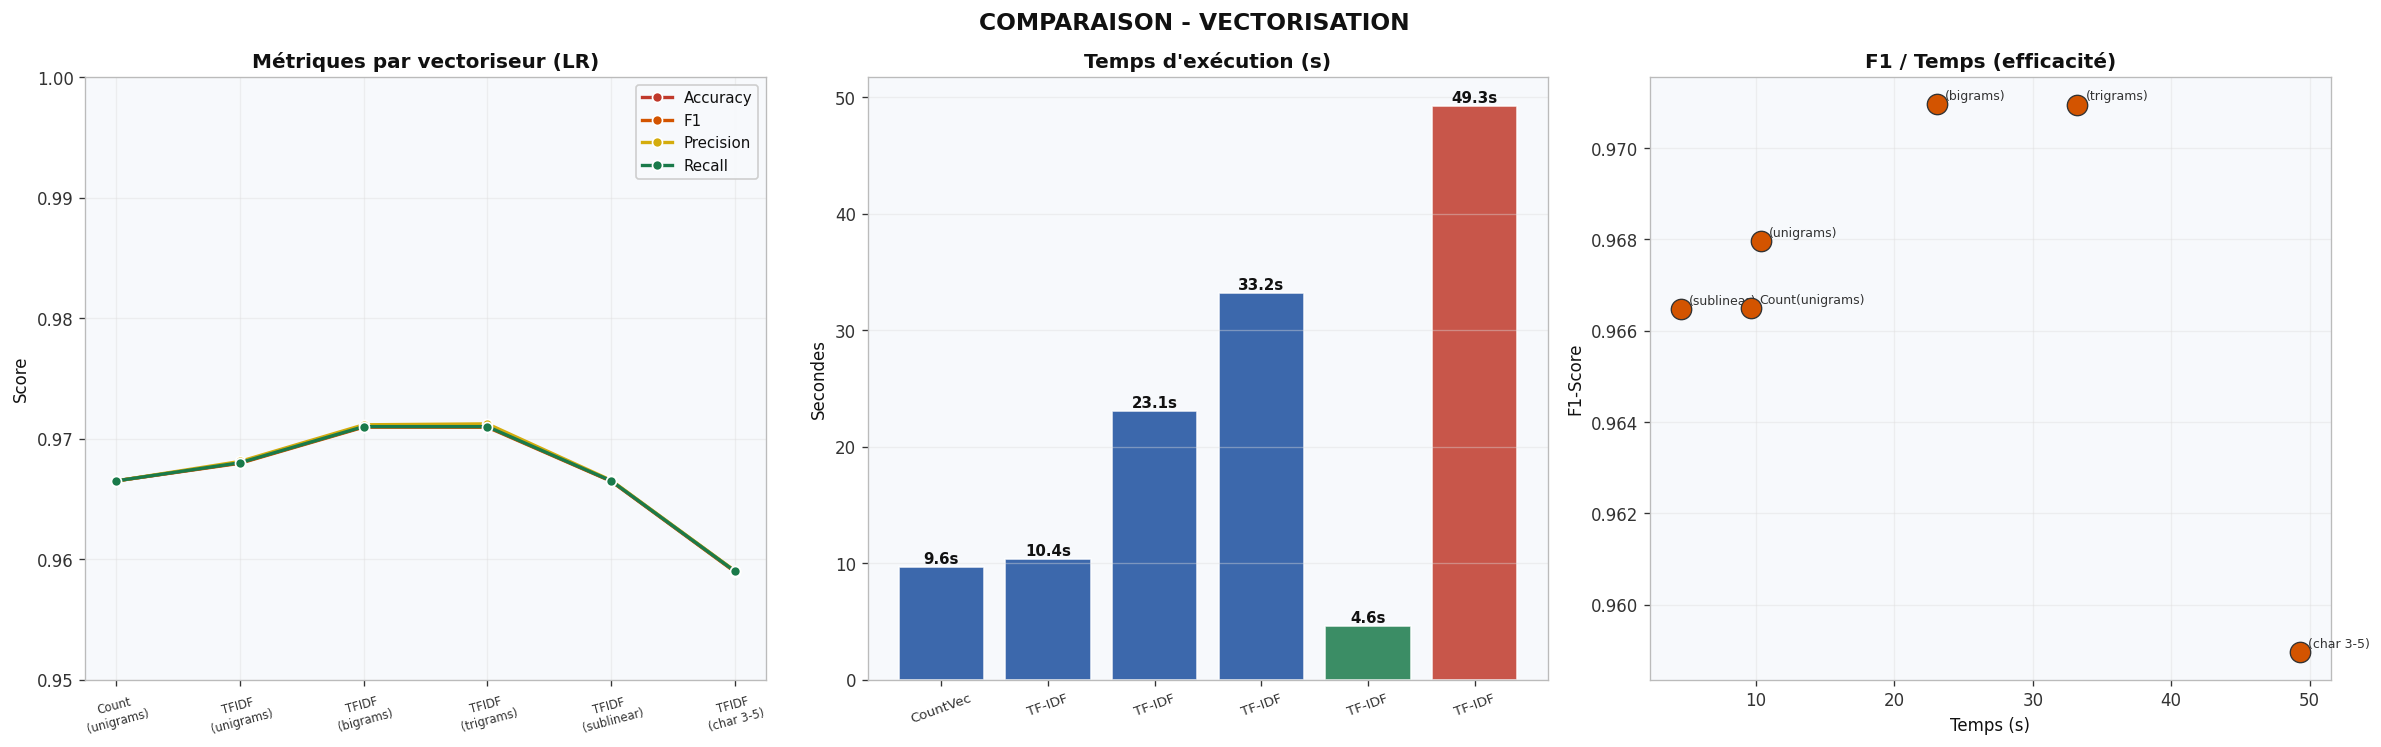

In [230]:
# CELL 8 vectorizer visualisation
# =============================================

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.patch.set_facecolor('white')
metrics = ['accuracy','f1','precision','recall']
names   = list(vec_results.keys())
x       = np.arange(len(names))

ax = axes[0]
for i,metric in enumerate(metrics):
    ax.plot(x,[vec_results[n][metric] for n in names],'o-',label=metric.capitalize(),
        color=COLORS['gradient'][i],linewidth=2,markersize=6,markeredgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels([n.replace('TF-IDF ','TFIDF\n').replace('CountVec ','Count\n')
                for n in names], fontsize=7, rotation=15)
ax.set_title('Métriques par vectoriseur (LR)', fontsize=12, fontweight='bold')
ax.set_ylabel('Score'); ax.set_ylim(0.95,1.0); ax.legend(fontsize=9); ax.grid(alpha=0.4)

ax = axes[1]
times  = [vec_results[n]['time'] for n in names]
ctimes = [COLORS['real'] if t==min(times) else COLORS['fake'] if t==max(times) else COLORS['neutral'] for t in times]
bars   = ax.bar(range(len(names)),times,color=ctimes,alpha=0.85,edgecolor='white')
for bar,t in zip(bars,times):
    ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.05,
            f'{t:.1f}s',ha='center',va='bottom',fontsize=9,fontweight='bold')
ax.set_xticks(range(len(names)))
ax.set_xticklabels([n.split('(')[0].strip() for n in names],fontsize=8,rotation=20)
ax.set_title("Temps d'exécution (s)", fontsize=12, fontweight='bold')
ax.set_ylabel('Secondes'); ax.grid(axis='y',alpha=0.4)

ax = axes[2]
for name in names:
    ax.scatter(vec_results[name]['time'],vec_results[name]['f1'],
            s=150,zorder=5,color=COLORS['accent'],edgecolors='#333333',linewidths=0.8)
    ax.annotate(name.replace('TF-IDF ','').replace('CountVec ','Count'),
                (vec_results[name]['time'],vec_results[name]['f1']),
                xytext=(5,3),textcoords='offset points',fontsize=7.5,color='#333333')
ax.set_title('F1 / Temps (efficacité)', fontsize=12, fontweight='bold')
ax.set_xlabel('Temps (s)'); ax.set_ylabel('F1-Score'); ax.grid(alpha=0.4)

plt.tight_layout()
fig.suptitle('COMPARAISON - VECTORISATION',fontsize=14,fontweight='bold',y=1.03)
save_fig('03_vectorization_comparison.png'); 
plt.show()


In [231]:

from sklearn.ensemble import VotingClassifier


def evaluate_model(model, X_tr, y_tr, X_ev, y_ev):
    t0 = time.time()
    model.fit(X_tr, y_tr)
    elapsed = time.time() - t0
    y_pred  = model.predict(X_ev)
    try:
        y_prob = model.predict_proba(X_ev)[:, 1]
        auc    = roc_auc_score(y_ev, y_prob)
    except AttributeError:
        try:
            y_prob = model.decision_function(X_ev)
            auc    = roc_auc_score(y_ev, y_prob)
            y_prob = None
        except AttributeError:
            y_prob = None
            auc    = roc_auc_score(y_ev, y_pred)
    return {'accuracy':  accuracy_score(y_ev, y_pred),
            'f1':        f1_score(y_ev, y_pred),
            'precision': precision_score(y_ev, y_pred),
            'recall':    recall_score(y_ev, y_pred),
            'roc_auc':   auc,
            'time':      elapsed,
            'y_pred':    y_pred,
            'y_prob':    y_prob}


models = {
    'Naïve Bayes':           MultinomialNB(alpha=0.1),
    'Régression Logistique': LogisticRegression(C=1.0,max_iter=300,
                                random_state=RANDOM_STATE,solver='liblinear'),
    'LinearSVC':             CalibratedClassifierCV(LinearSVC(C=0.5,max_iter=500,
                                        random_state=RANDOM_STATE,dual='auto')),
    'Arbre de Décision':     DecisionTreeClassifier(max_depth=20,random_state=RANDOM_STATE),
    'Forêt Aléatoire':       RandomForestClassifier(n_estimators=100,n_jobs=-1,
                                random_state=RANDOM_STATE),
    'Gradient Boosting':    GradientBoostingClassifier(n_estimators=100,
                                random_state=RANDOM_STATE),
    'Réseau de Neurones (MLP)': MLPClassifier(
        hidden_layer_sizes=(128,64), max_iter=100, random_state=RANDOM_STATE,
        early_stopping=True, validation_fraction=0.1,
        n_iter_no_change=10, verbose=False, learning_rate_init=0.001),
    'Voting Ensemble': VotingClassifier(estimators=[
    ('lr',  LogisticRegression(C=1.0, max_iter=500, random_state=42)),
    ('svc', LinearSVC(C=0.5, max_iter=2000, random_state=42)),
    ('nb',  MultinomialNB(alpha=0.1))
], voting='hard')
}

results        = {}
trained_models = {}

print('"Training" & Evaluation sur VALIDATION\n')
for name, model in models.items():
    res = evaluate_model(model, X_train_vec, y_train, X_val_vec, y_val)
    results[name] = res; trained_models[name] = model
    print(f'  {name:<42} F1={res["f1"]:.4f}  AUC={res["roc_auc"]:.4f}  ({res["time"]:.1f}s)')
    

best_name = max(results, key=lambda k: results[k]['f1'])
print(f'\nMeilleur modèle (val) : {best_name}  F1={results[best_name]["f1"]:.4f}')

"Training" & Evaluation sur VALIDATION

  Naïve Bayes                                F1=0.9586  AUC=0.9896  (0.1s)
  Régression Logistique                      F1=0.9844  AUC=0.9982  (1.8s)
  LinearSVC                                  F1=0.9910  AUC=0.9990  (2.5s)
  Arbre de Décision                          F1=0.9520  AUC=0.9382  (35.9s)
  Forêt Aléatoire                            F1=0.9770  AUC=0.9977  (20.3s)
  Gradient Boosting                          F1=0.9702  AUC=0.9955  (405.1s)
  Réseau de Neurones (MLP)                   F1=0.9900  AUC=0.9986  (646.9s)
  Voting Ensemble                            F1=0.9863  AUC=0.9839  (1.3s)

Meilleur modèle (val) : LinearSVC  F1=0.9910


Analyse de sensibilité — paramètre C (LinearSVC)...
  C=0.001    Train F1=0.8913 | Val F1=0.8852
  C=0.01     Train F1=0.9671 | Val F1=0.9647
  C=0.1      Train F1=0.9920 | Val F1=0.9850
  C=0.5      Train F1=0.9987 | Val F1=0.9902
  C=1.0      Train F1=0.9999 | Val F1=0.9912
  C=2.0      Train F1=1.0000 | Val F1=0.9915
  C=5.0      Train F1=1.0000 | Val F1=0.9912
  C=10.0     Train F1=1.0000 | Val F1=0.9907
  C=50.0     Train F1=1.0000 | Val F1=0.9898

Meilleur C = 0.5  (sélectionné sur val set)

Courbe d'apprentissage (CV=5)...
Figure sauvegardée : figures\05_hyperparameter_analysis.png


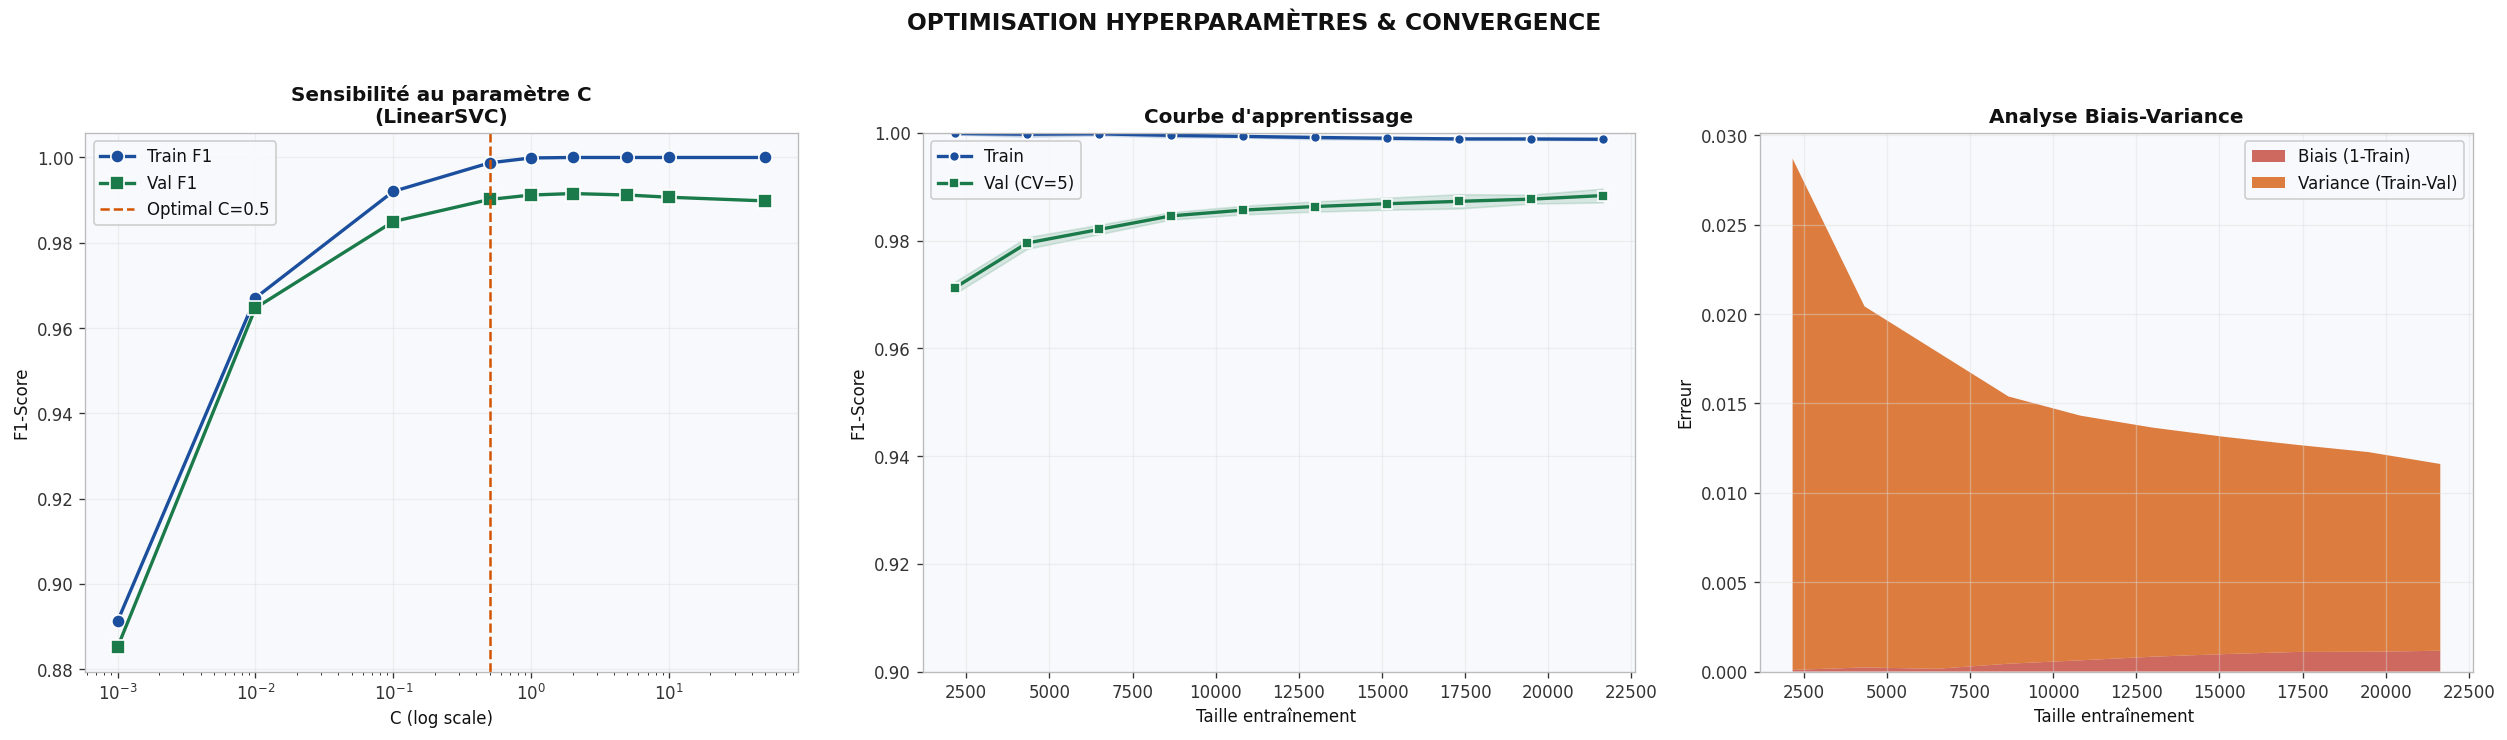

In [ ]:
#Cell 10 - hyperparameter tuning
# ===================================================
#print('Analyse de sensibilité — paramètre C (Régression Logistique)...')
print('Analyse de sensibilité — paramètre C (LinearSVC)...')
C_values  = [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 50.0]
C_results = {'train_f1': [], 'val_f1': []}

for C in C_values:
    # clf = LogisticRegression(C=C, max_iter=500, random_state=RANDOM_STATE,
    #                         solver='liblinear')   
    clf = LinearSVC(C=C, max_iter=500, random_state=RANDOM_STATE, dual='auto') 
    clf.fit(X_train_vec, y_train)
    C_results['train_f1'].append(f1_score(y_train, clf.predict(X_train_vec), average='weighted'))
    C_results['val_f1'].append(  f1_score(y_val,   clf.predict(X_val_vec),   average='weighted'))
    print(f'  C={C:<8} Train F1={C_results["train_f1"][-1]:.4f} | Val F1={C_results["val_f1"][-1]:.4f}')


max_val_f1 = max(C_results['val_f1'])
best_C = next(C for C, vf in zip(C_values, C_results['val_f1']) if vf >= max_val_f1 - 0.002)
print(f'\nMeilleur C = {best_C}  (sélectionné sur val set)')

print("\nCourbe d'apprentissage (CV=5)...")
#final_clf = LogisticRegression(C=best_C, max_iter=500, random_state=RANDOM_STATE, solver='liblinear', n_jobs=-1)
final_clf = LinearSVC(C=best_C, max_iter=500, random_state=RANDOM_STATE, dual='auto')
train_sizes, train_scores, val_scores = learning_curve(
    final_clf, X_train_vec, y_train,
    train_sizes=np.linspace(0.1,1.0,10), cv=5, scoring='f1_weighted', n_jobs=-1)

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.patch.set_facecolor('white')

ax = axes[0]
ax.semilogx(C_values, C_results['train_f1'],'o-',color=COLORS['neutral'],
            linewidth=2,markersize=8,label='Train F1',markeredgecolor='white')
ax.semilogx(C_values, C_results['val_f1'],  's-',color=COLORS['real'],
            linewidth=2,markersize=8,label='Val F1',  markeredgecolor='white')
ax.axvline(x=best_C,color=COLORS['accent'],linestyle='--',linewidth=1.5,label=f'Optimal C={best_C}')
ax.set_xlabel('C (log scale)'); ax.set_ylabel('F1-Score')
#ax.set_title('Sensibilité au paramètre C\n(Régression Logistique)', fontsize=12, fontweight='bold')
ax.set_title('Sensibilité au paramètre C\n(LinearSVC)', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(alpha=0.4)

ax = axes[1]
tr_m,tr_s = train_scores.mean(1),train_scores.std(1)
va_m,va_s = val_scores.mean(1),  val_scores.std(1)
ax.fill_between(train_sizes,tr_m-tr_s,tr_m+tr_s,alpha=0.15,color=COLORS['neutral'])
ax.fill_between(train_sizes,va_m-va_s,va_m+va_s,alpha=0.15,color=COLORS['real'])
ax.plot(train_sizes,tr_m,'o-',color=COLORS['neutral'],linewidth=2,markersize=6,
        label='Train',markeredgecolor='white')
ax.plot(train_sizes,va_m,'s-',color=COLORS['real'],   linewidth=2,markersize=6,
        label='Val (CV=5)',markeredgecolor='white')
ax.set_xlabel("Taille entraînement "); ax.set_ylabel('F1-Score')
ax.set_title("Courbe d'apprentissage", fontsize=12, fontweight='bold')
ax.legend(); ax.grid(alpha=0.4); ax.set_ylim(0.90,1.0)

ax = axes[2]
bias=1-tr_m; variance=tr_m-va_m
ax.stackplot(train_sizes,bias,variance,
            labels=['Biais (1-Train)','Variance (Train-Val)'],
            colors=[COLORS['fake'],COLORS['accent']],alpha=0.75)
ax.set_xlabel("Taille entraînement "); ax.set_ylabel('Erreur')
ax.set_title('Analyse Biais-Variance', fontsize=12, fontweight='bold')
ax.legend(loc='upper right'); ax.grid(alpha=0.4)

fig.suptitle('OPTIMISATION HYPERPARAMÈTRES & CONVERGENCE',fontsize=14,fontweight='bold',y=1.02)
plt.tight_layout(); save_fig('05_hyperparameter_analysis.png'); 
plt.show()

In [233]:
# # CELL 12 final model  - LR
# # ===================================================
# X_trainval_vec = sp_vstack([X_train_vec, X_val_vec])
# y_trainval     = pd.concat([y_train, y_val])

# assert len(set(idx_test) & set(list(idx_train) + list(idx_val))) == 0

# final_model = logisticRegression = LogisticRegression(C=best_C, max_iter=500, random_state=RANDOM_STATE, solver='liblinear', n_jobs=-1)
# final_model.fit(X_trainval_vec, y_trainval)

# y_pred_final = final_model.predict(X_test_vec)
# y_prob_final = final_model.predict_proba(X_test_vec)[:, 1]

# print('RAPPORT FINAL (TEST SET)')
# print('='*55)
# print(classification_report(y_test, y_pred_final, target_names=['FAUX','VRAI']))
# print(f'ROC-AUC  : {roc_auc_score(y_test, y_prob_final):.6f}')
# print(f'Accuracy : {accuracy_score(y_test, y_pred_final):.6f}')

# test_df         = X_test_raw.reset_index(drop=True).to_frame()
# test_df['true'] = y_test.reset_index(drop=True)
# test_df['pred'] = y_pred_final
# test_df['prob'] = y_prob_final
# errors = test_df[test_df['true'] != test_df['pred']]
# fp     = test_df[(test_df['true']==0) & (test_df['pred']==1)]
# fn     = test_df[(test_df['true']==1) & (test_df['pred']==0)]
# print(f'\nErreurs: {len(errors)} ({len(errors)/len(test_df)*100:.2f}%) | FP:{len(fp)} FN:{len(fn)}')

# feature_names = np.array(vectorizer.get_feature_names_out())

# if hasattr(final_model, 'coef_'):
#     coefficients  = final_model.coef_[0]
#     top_n = 20
#     top_fake_idx = np.argsort(coefficients)[:top_n]
#     top_real_idx = np.argsort(coefficients)[-top_n:][::-1]
    


In [234]:
# CELL 12 final model  - SVC
# ===================================================
X_trainval_vec = sp_vstack([X_train_vec, X_val_vec])
y_trainval     = pd.concat([y_train, y_val])

assert len(set(idx_test) & set(list(idx_train) + list(idx_val))) == 0

base_svc = LinearSVC(C=0.5, max_iter=500, random_state=RANDOM_STATE, dual='auto')
base_svc.fit(X_trainval_vec, y_trainval)

final_model = CalibratedClassifierCV(base_svc)
final_model.fit(X_trainval_vec, y_trainval)

y_pred_final = final_model.predict(X_test_vec)
y_prob_final = final_model.predict_proba(X_test_vec)[:, 1]

print(classification_report(y_test, y_pred_final, target_names=['FAUX','VRAI']))
print(f'ROC-AUC  : {roc_auc_score(y_test, y_prob_final):.6f}')
print(f'Accuracy : {accuracy_score(y_test, y_pred_final):.6f}')

test_df         = X_test_raw.reset_index(drop=True).to_frame()
test_df['true'] = y_test.reset_index(drop=True)
test_df['pred'] = y_pred_final
test_df['prob'] = y_prob_final
errors = test_df[test_df['true'] != test_df['pred']]
fp     = test_df[(test_df['true']==0) & (test_df['pred']==1)]
fn     = test_df[(test_df['true']==1) & (test_df['pred']==0)]
print(f'\nErreurs: {len(errors)} ({len(errors)/len(test_df)*100:.2f}%) | FP:{len(fp)} FN:{len(fn)}')

feature_names = np.array(vectorizer.get_feature_names_out())

if hasattr(base_svc, 'coef_'):
    coefficients  = base_svc.coef_[0]
    top_n = 20
    top_fake_idx = np.argsort(coefficients)[:top_n]
    top_real_idx = np.argsort(coefficients)[-top_n:][::-1]


              precision    recall  f1-score   support

        FAUX       0.99      0.99      0.99      2618
        VRAI       0.99      0.99      0.99      3179

    accuracy                           0.99      5797
   macro avg       0.99      0.99      0.99      5797
weighted avg       0.99      0.99      0.99      5797

ROC-AUC  : 0.999140
Accuracy : 0.988787

Erreurs: 65 (1.12%) | FP:39 FN:26


In [235]:
# # CELL 12 final model  - Gradient Boosting
# # ===================================================
# X_trainval_vec = sp_vstack([X_train_vec, X_val_vec])
# y_trainval     = pd.concat([y_train, y_val])

# assert len(set(idx_test) & set(list(idx_train) + list(idx_val))) == 0

# base_svc = GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE)
# base_svc.fit(X_trainval_vec, y_trainval)

# final_model = Calibrat(base_svc)
# final_model.fit(X_trainval_vec, y_trainval)

# y_pred_final = final_model.predict(X_test_vec)
# y_prob_final = final_model.predict_proba(X_test_vec)[:, 1]


# print(classification_report(y_test, y_pred_final, target_names=['FAUX','VRAI']))
# print(f'ROC-AUC  : {roc_auc_score(y_test, y_prob_final):.6f}')
# print(f'Accuracy : {accuracy_score(y_test, y_pred_final):.6f}')

# test_df         = X_test_raw.reset_index(drop=True).to_frame()
# test_df['true'] = y_test.reset_index(drop=True)
# test_df['pred'] = y_pred_final
# test_df['prob'] = y_prob_final
# errors = test_df[test_df['true'] != test_df['pred']]
# fp     = test_df[(test_df['true']==0) & (test_df['pred']==1)]
# fn     = test_df[(test_df['true']==1) & (test_df['pred']==0)]
# print(f'\nErreurs: {len(errors)} ({len(errors)/len(test_df)*100:.2f}%) | FP:{len(fp)} FN:{len(fn)}')

# feature_names = np.array(vectorizer.get_feature_names_out())

# if hasattr(base_svc, 'coef_'):
#     coefficients  = base_svc.coef_[0]
#     top_n = 20
#     top_fake_idx = np.argsort(coefficients)[:top_n]
#     top_real_idx = np.argsort(coefficients)[-top_n:][::-1]


Figure sauvegardée : figures\06_model_interpretability.png


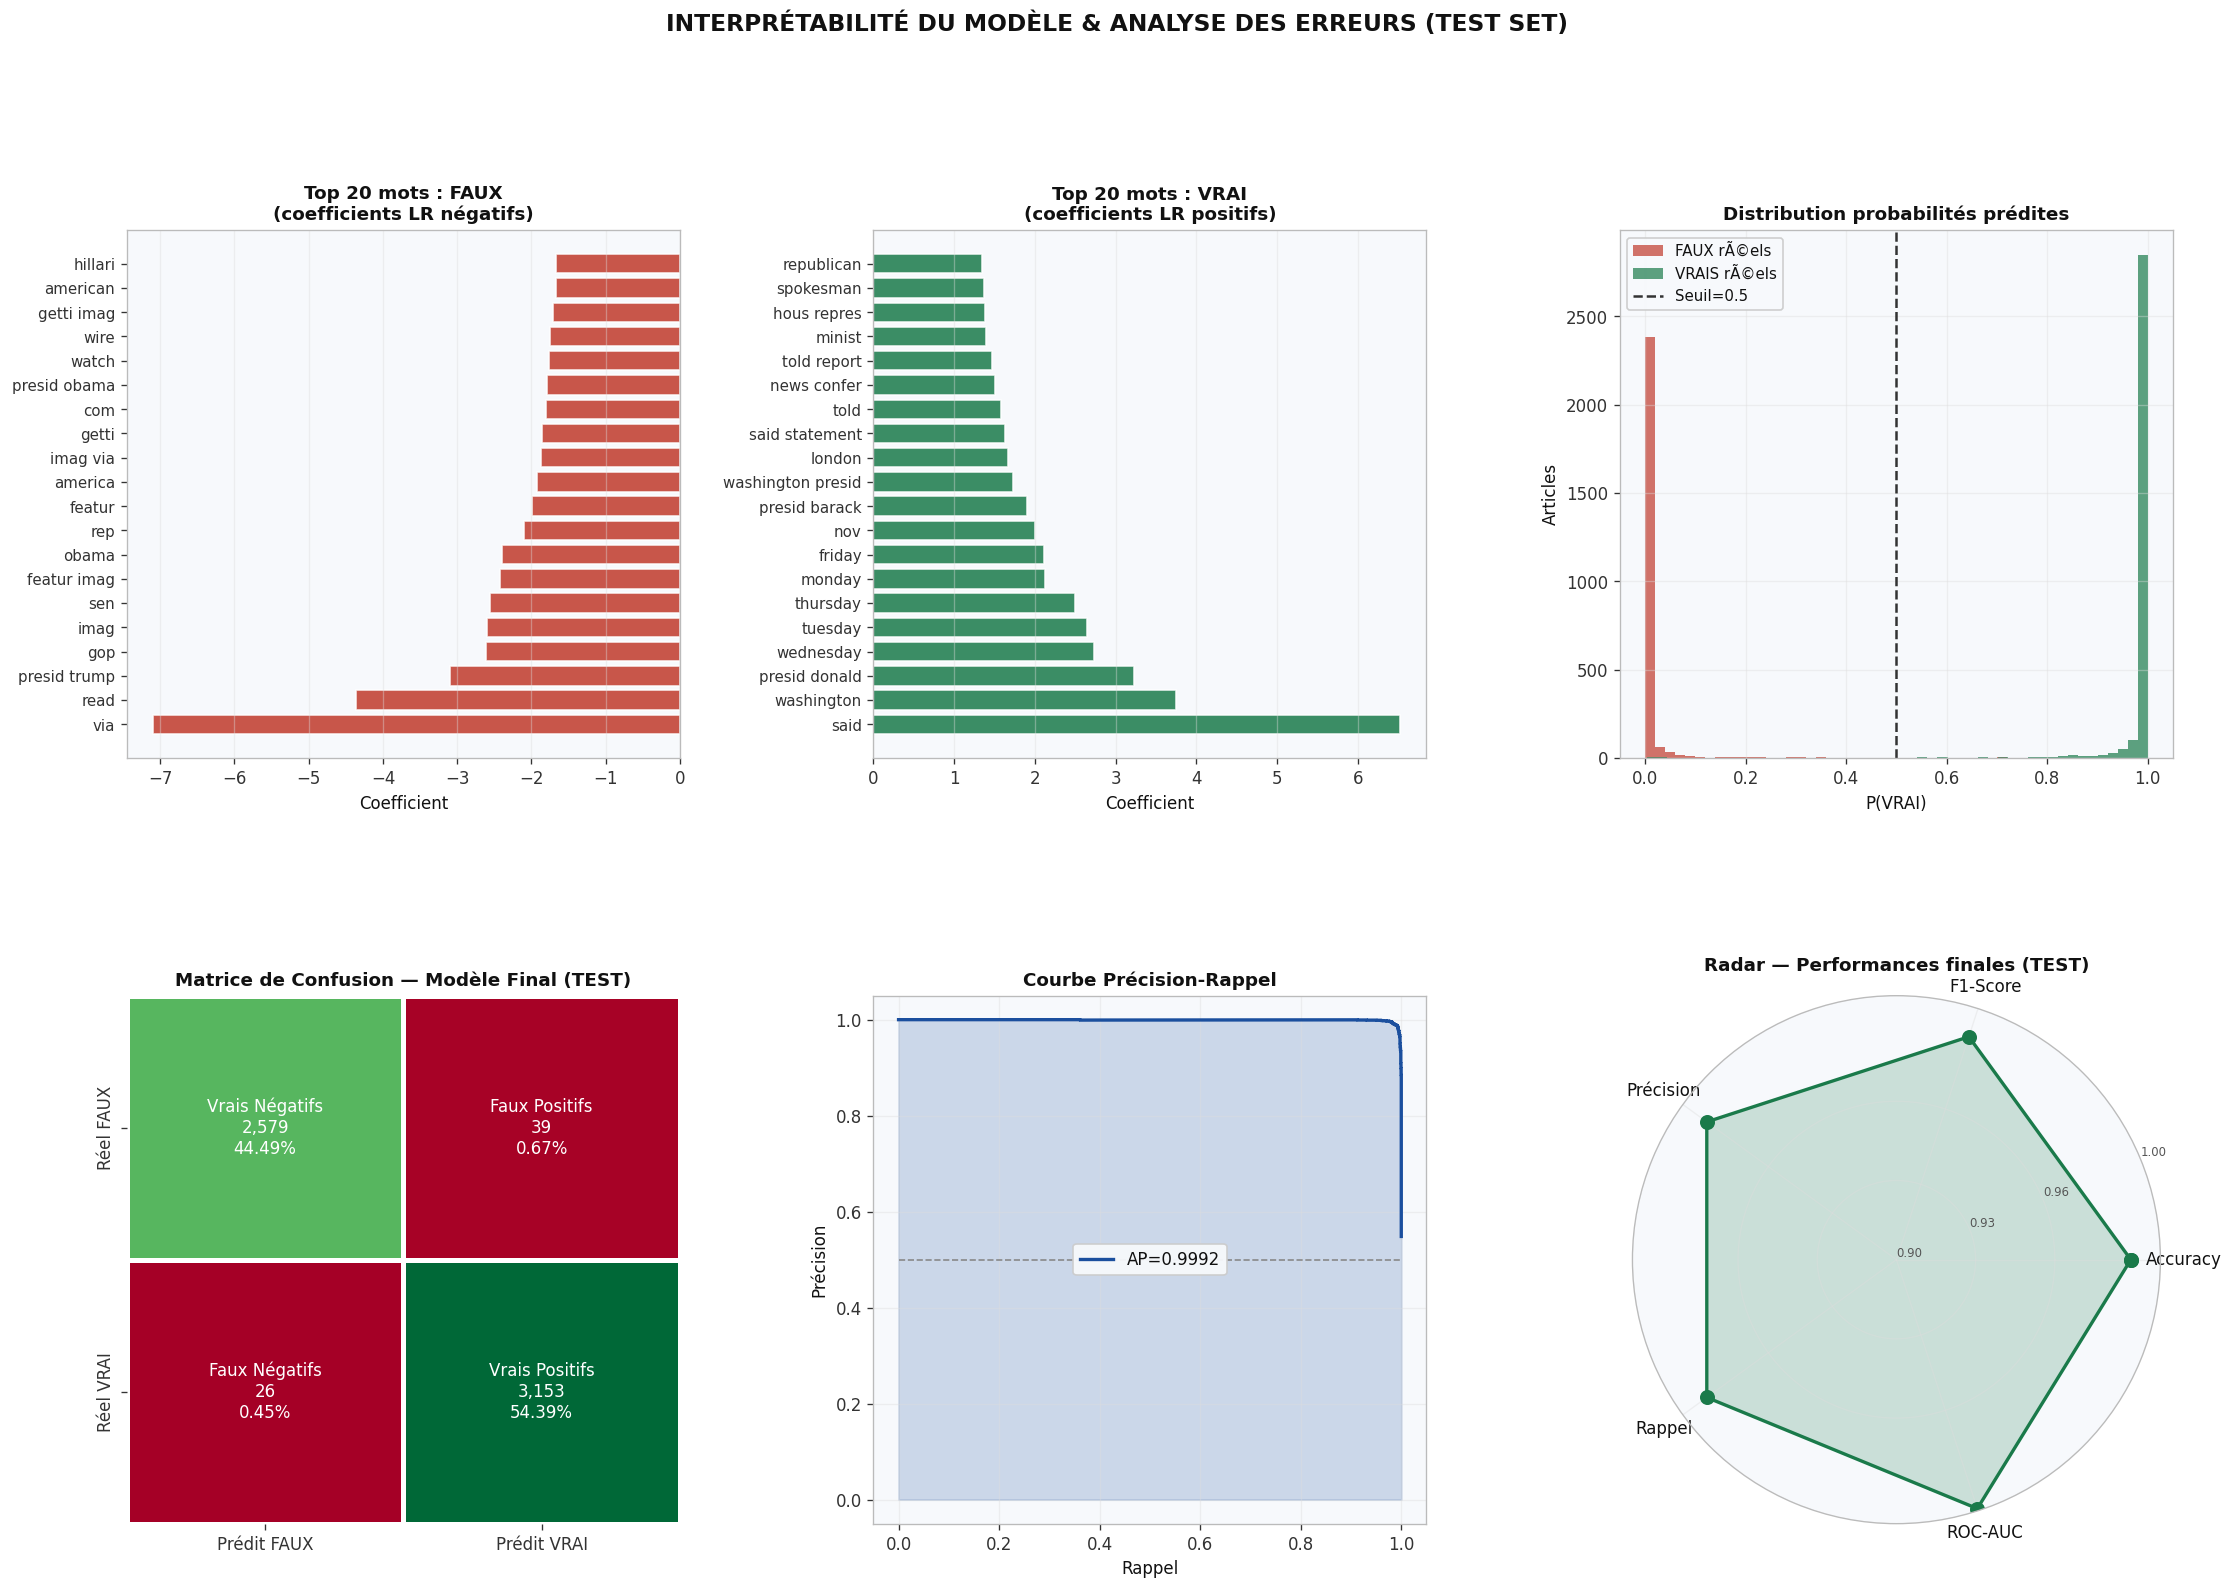

In [ ]:
# CELL 13   visualisation
# ==============================================================

fig = plt.figure(figsize=(22,14)); fig.patch.set_facecolor('white')

gs  = gridspec.GridSpec(2, 3, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0,0]); ax1.set_facecolor('#F7F9FC')
ax1.barh(range(top_n), coefficients[top_fake_idx], color=COLORS['fake'], alpha=0.85, edgecolor='white')
ax1.set_yticks(range(top_n)); ax1.set_yticklabels(feature_names[top_fake_idx], fontsize=9)
ax1.set_title('Top 20 mots : FAUX\n(coefficients LR négatifs)', fontsize=11, fontweight='bold')
ax1.set_xlabel('Coefficient'); ax1.grid(axis='x',alpha=0.4)

ax2 = fig.add_subplot(gs[0,1]); ax2.set_facecolor('#F7F9FC')
ax2.barh(range(top_n), coefficients[top_real_idx], color=COLORS['real'], alpha=0.85, edgecolor='white')
ax2.set_yticks(range(top_n)); ax2.set_yticklabels(feature_names[top_real_idx], fontsize=9)
ax2.set_title('Top 20 mots : VRAI\n(coefficients LR positifs)', fontsize=11, fontweight='bold')
ax2.set_xlabel('Coefficient'); ax2.grid(axis='x',alpha=0.4)

ax3 = fig.add_subplot(gs[0,2]); ax3.set_facecolor('#F7F9FC')
ax3.hist(y_prob_final[y_test==0],bins=50,alpha=0.7,color=COLORS['fake'],label='FAUX réels')
ax3.hist(y_prob_final[y_test==1],bins=50,alpha=0.7,color=COLORS['real'],label='VRAIS réels')
ax3.axvline(x=0.5,color='#333333',linestyle='--',linewidth=1.5,label='Seuil=0.5')
ax3.set_xlabel('P(VRAI)'); ax3.set_ylabel('Articles'); ax3.set_xlim(-0.05,1.05)
ax3.set_title('Distribution probabilités prédites', fontsize=11, fontweight='bold')
ax3.legend(fontsize=9); ax3.grid(alpha=0.4)

ax4 = fig.add_subplot(gs[1,0])
cm_final   = confusion_matrix(y_test, y_pred_final)
gnames     = ['Vrais Négatifs','Faux Positifs','Faux Négatifs','Vrais Positifs']
gcounts    = [f'{v:,}' for v in cm_final.flatten()]
gpct       = [f'{v:.2%}' for v in cm_final.flatten()/cm_final.sum()]
ann        = np.array([[f'{n}\n{c}\n{p}' for n,c,p in zip(gnames[:2],gcounts[:2],gpct[:2])],
                        [f'{n}\n{c}\n{p}' for n,c,p in zip(gnames[2:],gcounts[2:],gpct[2:])]])
sns.heatmap(cm_final,annot=ann,fmt='',ax=ax4,cmap='RdYlGn',linewidths=2,linecolor='white',
            annot_kws={'size':10},xticklabels=['Prédit FAUX','Prédit VRAI'],
            yticklabels=['Réel FAUX','Réel VRAI'],cbar=False)
ax4.set_title('Matrice de Confusion — Modèle Final (TEST)', fontsize=11, fontweight='bold')

ax5 = fig.add_subplot(gs[1,1]); ax5.set_facecolor('#F7F9FC')
prec_c,rec_c,_ = precision_recall_curve(y_test,y_prob_final)
ap = average_precision_score(y_test,y_prob_final)
ax5.fill_between(rec_c,prec_c,alpha=0.2,color=COLORS['neutral'])
ax5.plot(rec_c,prec_c,color=COLORS['neutral'],linewidth=2,label=f'AP={ap:.4f}')
ax5.plot([0,1],[0.5,0.5],'--',color='#888888',linewidth=1)
ax5.set_xlabel('Rappel'); ax5.set_ylabel('Précision')
ax5.set_title('Courbe Précision-Rappel', fontsize=11, fontweight='bold')
ax5.legend(); ax5.grid(alpha=0.4)

fm = {'Accuracy': accuracy_score(y_test,y_pred_final),
    'F1-Score': f1_score(y_test,y_pred_final,average='weighted'),
    'Précision':precision_score(y_test,y_pred_final,average='weighted',zero_division=0),
    'Rappel':   recall_score(y_test,y_pred_final,average='weighted'),
    'ROC-AUC':  roc_auc_score(y_test,y_prob_final)}
cats   = list(fm.keys()); vals = list(fm.values())
angles = np.linspace(0,2*np.pi,len(cats),endpoint=False).tolist()
vr = vals+vals[:1]; ar = angles+angles[:1]
ax6 = fig.add_subplot(gs[1,2],polar=True); ax6.set_facecolor('#F7F9FC')
ax6.plot(ar,vr,'o-',color=COLORS['real'],linewidth=2,markersize=8)
ax6.fill(ar,vr,color=COLORS['real'],alpha=0.20)
ax6.set_xticks(angles); ax6.set_xticklabels(cats,fontsize=10,color='#111111')
ax6.set_ylim(0.90,1.0); ax6.set_yticks([0.90,0.93,0.96,1.0])
ax6.set_yticklabels(['0.90','0.93','0.96','1.00'],fontsize=7,color='#555555')
ax6.set_title('Radar — Performances finales (TEST)',fontsize=11,fontweight='bold',pad=15); ax6.grid(alpha=0.4)

fig.suptitle('INTERPRÉTABILITÉ DU MODÈLE & ANALYSE DES ERREURS (TEST SET)',
            fontsize=14, fontweight='bold', y=1.01)
save_fig('06_model_interpretability.png'); 
plt.show()

Figure sauvegardée : figures\07_final_comparison_all_families.png


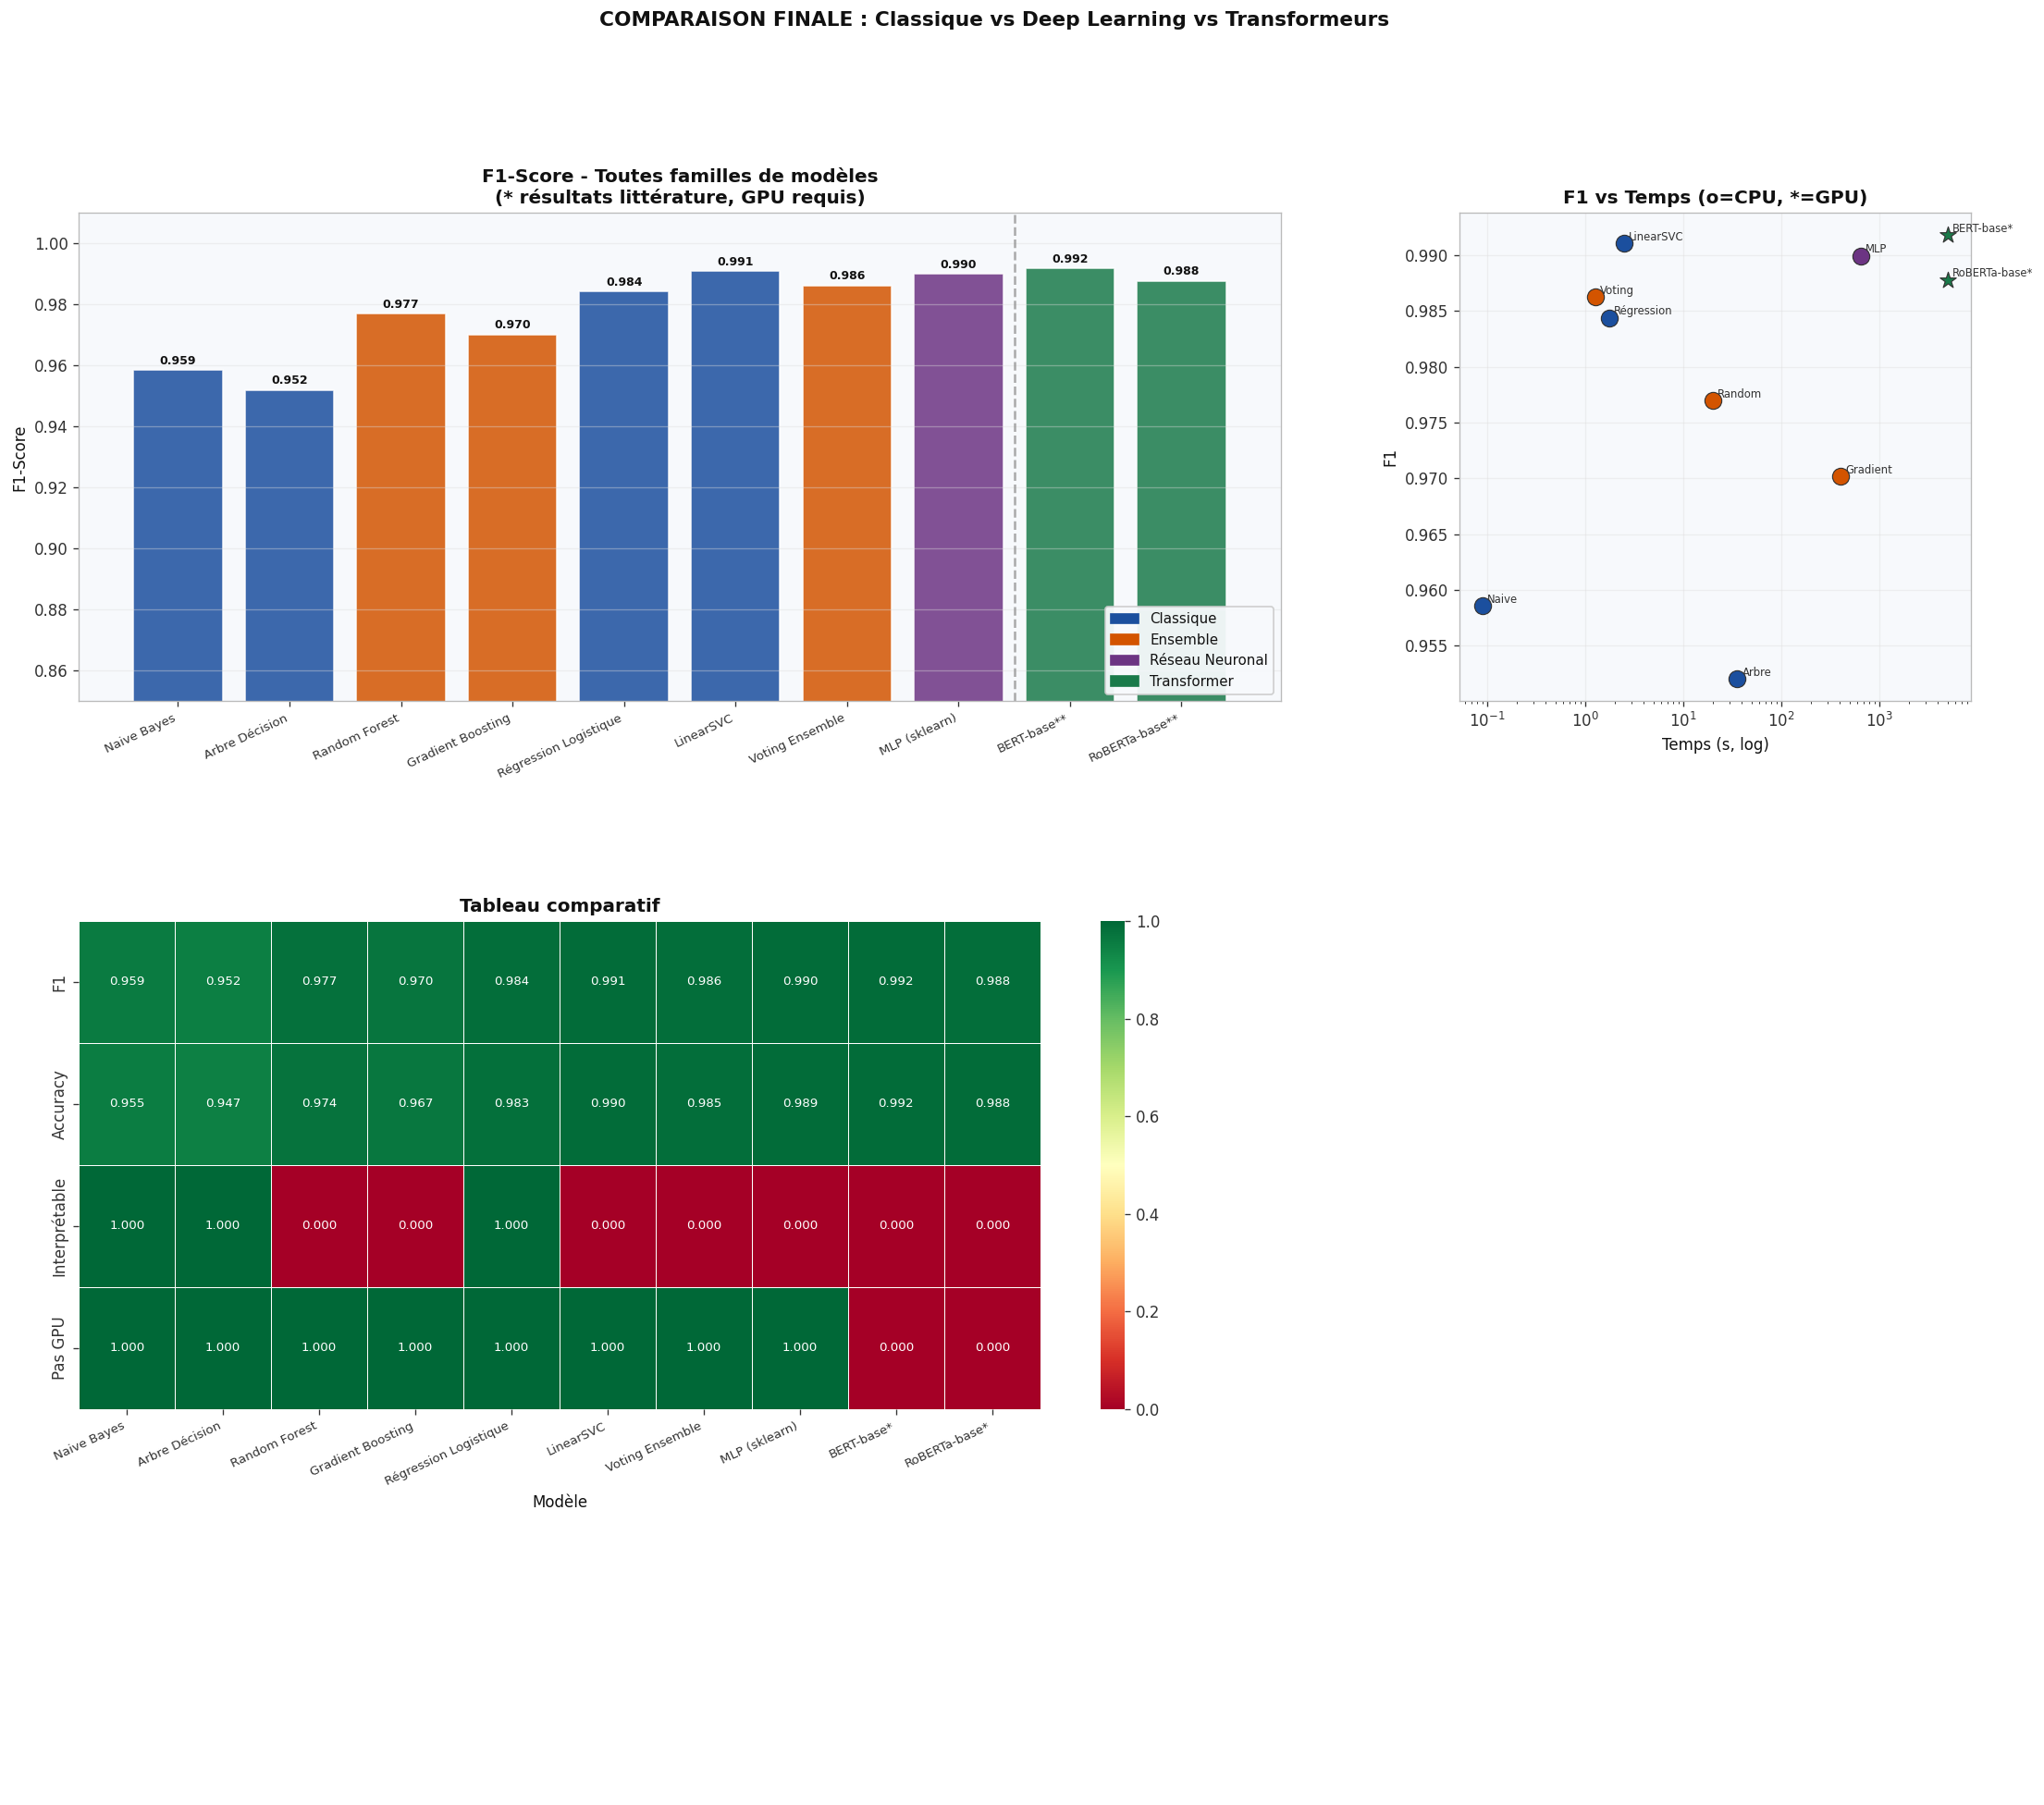

In [ ]:
# CELL 14 final comparison all families
# ==============================================================
#transformer model executed here https://colab.research.google.com/drive/1QyL8ekpuwX6OT2vI5pfA18Gy5e6o3FCY?authuser=3#scrollTo=RGpcQtRJ6x7y

#results with minimal data cleaning - cell 1 in google colab
# Modèle          Acc      F1       Prec     Rec      AUC      Temps(min)    Temps(s)
# ----------------------------------------------------------------------------
# BERT-base       0.9996  0.9995  1.0000    0.9991     1.0000      88.7     5322
# RoBERTa-base    1.0000  1.0000  1.0000    1.0000     1.0000      88.9     5334

#results with the last data cleaning strategy - cell 2 in google colab
# Modèle          Acc      F1       Prec     Rec      AUC      Temps(min)    Temps(s)
# ----------------------------------------------------------------------------
# BERT-base      0.9921   0.9918   0.9910   0.9925    0.9996    83.7        5022
# RoBERTa-base   0.9883  0.9878    0.9824   0.9932    0.9992    84.0        5040

comparison_data = {
    'Modèle':   ['Naive Bayes','Arbre Décision',
                'Random Forest','Gradient Boosting',
                'Régression Logistique','LinearSVC','Voting Ensemble',
                'MLP (sklearn)',
                'BERT-base*','RoBERTa-base*'],
    'Famille':  ['Classique','Classique','Ensemble','Ensemble',
                'Classique','Classique','Ensemble','Réseau Neuronal',
                'Transformer','Transformer'],
    'Accuracy': [results.get('Naïve Bayes',          {}).get('accuracy', float('nan')),
                results.get('Arbre de Décision',     {}).get('accuracy', float('nan')),
                results.get('Forêt Aléatoire',       {}).get('accuracy', float('nan')),
                results.get('Gradient Boosting',     {}).get('accuracy', float('nan')),
                results.get('Régression Logistique', {}).get('accuracy', float('nan')),
                results.get('LinearSVC',             {}).get('accuracy', float('nan')),
                results.get('Voting Ensemble',          {}).get('accuracy', float('nan')),
                results.get('Réseau de Neurones (MLP)',{}).get('accuracy',float('nan')),
                0.9921, 0.9883],
    'F1':       [results.get('Naïve Bayes',          {}).get('f1', float('nan')),
                results.get('Arbre de Décision',     {}).get('f1', float('nan')),
                results.get('Forêt Aléatoire',       {}).get('f1', float('nan')),
                results.get('Gradient Boosting',     {}).get('f1', float('nan')),
                results.get('Régression Logistique', {}).get('f1', float('nan')),
                results.get('LinearSVC',             {}).get('f1', float('nan')),
                results.get('Voting Ensemble',          {}).get('f1', float('nan')),
                results.get('Réseau de Neurones (MLP)',{}).get('f1', float('nan')),
                0.9918, 0.9878],
    'Temps (s)':[results.get('Naïve Bayes',          {}).get('time', float('nan')),
                results.get('Arbre de Décision',     {}).get('time', float('nan')),
                results.get('Forêt Aléatoire',       {}).get('time', float('nan')),
                results.get('Gradient Boosting',     {}).get('time', float('nan')),
                results.get('Régression Logistique', {}).get('time', float('nan')),
                results.get('LinearSVC',             {}).get('time', float('nan')),
                results.get('Voting Ensemble',          {}).get('time', float('nan')),
                results.get('Réseau de Neurones (MLP)',{}).get('time', float('nan')),
                5022, 5040],
    'Interprétable':[True, True, False, False, True, False, False, False, False, False],
    'GPU requis':   [False,False,False,False,False,False,False,False,True,True],
}
comp_df = pd.DataFrame(comparison_data)
family_colors = {'Classique':'#1B4F9E','Ensemble':'#D35400',
                'Réseau Neuronal':'#6C3483','Transformer':'#1A7A4A'}

fig = plt.figure(figsize=(22,14)); fig.patch.set_facecolor('white')
gs  = gridspec.GridSpec(2,3,hspace=0.45,wspace=0.35)

ax1 = fig.add_subplot(gs[0,0:2]); ax1.set_facecolor('#F7F9FC')
c_bars = [family_colors[f] for f in comp_df['Famille']]
bars   = ax1.bar(range(len(comp_df)),comp_df['F1'].fillna(0),color=c_bars,alpha=0.85,edgecolor='white')
for i,(bar,row) in enumerate(zip(bars,comp_df.itertuples())):
    if pd.isna(row.F1):
        bar.set_hatch('///'); bar.set_alpha(0.35)
        ax1.text(bar.get_x()+bar.get_width()/2, 0.86,
                'N/A', ha='center', va='bottom', fontsize=7, color='#888888')
    else:
        ax1.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.001,
                f'{row.F1:.3f}',ha='center',va='bottom',fontsize=7.5,fontweight='bold')
    if comp_df.iloc[i]['GPU requis']:
        ax1.text(bar.get_x()+bar.get_width()/2,bar.get_height()/2,
                'GPU',ha='center',va='center',fontsize=7,color='white',fontweight='bold')
ax1.axvline(x=7.5,color='#888888',linestyle='--',linewidth=1.5,alpha=0.7)
ax1.set_xticks(range(len(comp_df)))
ax1.set_xticklabels([f"{r.Modèle}{'*' if comp_df.iloc[i]['GPU requis'] else ''}"
                    for i,r in enumerate(comp_df.itertuples())],rotation=25,ha='right',fontsize=8)
ax1.set_title('F1-Score - Toutes familles de modèles\n(* résultats littérature, GPU requis)',fontsize=12,fontweight='bold')
ax1.set_ylabel('F1-Score'); ax1.set_ylim(0.85,1.01); ax1.grid(axis='y',alpha=0.4)
ax1.legend(handles=[mpatches.Patch(color=c,label=f) for f,c in family_colors.items()],
        loc='lower right',fontsize=9)

ax2 = fig.add_subplot(gs[0,2]); ax2.set_facecolor('#F7F9FC')
for _,row in comp_df.iterrows():
    if pd.isna(row['F1']) or pd.isna(row['Temps (s)']):
        continue 
    ax2.scatter(row['Temps (s)'],row['F1'],color=family_colors[row['Famille']],s=120,
                marker='*' if row['GPU requis'] else 'o',zorder=5,edgecolors='#333333',linewidths=0.7)
    ax2.annotate(row['Modèle'].split(' ')[0],(row['Temps (s)'],row['F1']),
            xytext=(3,2),textcoords='offset points',fontsize=7,color='#333333')
ax2.set_xscale('log'); ax2.set_xlabel('Temps (s, log)'); ax2.set_ylabel('F1')
ax2.set_title('F1 vs Temps (o=CPU, *=GPU)',fontsize=12,fontweight='bold'); ax2.grid(alpha=0.4)

ax3 = fig.add_subplot(gs[1,0:2])
hm = comp_df[['Modèle','F1','Accuracy']].set_index('Modèle').copy()
hm['Interprétable'] = comp_df['Interprétable'].astype(float).values
hm['Pas GPU']       = (~comp_df['GPU requis']).astype(float).values
sns.heatmap(hm.T,annot=True,fmt='.3f',ax=ax3,cmap='RdYlGn',linewidths=0.5,annot_kws={'size':8})
ax3.set_title('Tableau comparatif',fontsize=12,fontweight='bold')
ax3.set_xticklabels(ax3.get_xticklabels(),rotation=25,ha='right',fontsize=8)

fig.suptitle('COMPARAISON FINALE : Classique vs Deep Learning vs Transformeurs',
            fontsize=13,fontweight='bold',y=1.01)
save_fig('07_final_comparison_all_families.png'); 
plt.show()


In [238]:
# CELL 16 SAVE + INTEGRATION TESTS
#===================================================
#Model & vectorizer 
joblib.dump(vectorizer,  MODELS_DIR/'vectorizer.joblib')
#joblib.dump(final_model, MODELS_DIR/'lr_final.joblib')
joblib.dump(final_model, MODELS_DIR/'lsvc_final.joblib')

#Pre-computed matrices
joblib.dump(X_train_vec,   MODELS_DIR/'X_train_vec.joblib')
joblib.dump(X_val_vec,     MODELS_DIR/'X_val_vec.joblib')
joblib.dump(X_test_vec,    MODELS_DIR/'X_test_vec.joblib')
joblib.dump(y_train,       MODELS_DIR/'y_train.joblib')
joblib.dump(y_val,         MODELS_DIR/'y_val.joblib')
joblib.dump(y_test,        MODELS_DIR/'y_test.joblib')
print('Matrices TF-IDF sauvegardées.')

#Metadata JSON
metadata = {
    'random_state': RANDOM_STATE,
    'split': {'train':len(y_train),'val':len(y_val),'test':len(y_test)},
    'vectorizer': {'max_features':50_000,'sublinear_tf':True,'min_df':3,'ngram_range':[1,2]},
    'best_C': best_C,
    'test_metrics': {
        'accuracy':  float(accuracy_score(y_test,y_pred_final)),
        'f1':        float(f1_score(y_test,y_pred_final,average='weighted')),
        'precision': float(precision_score(y_test,y_pred_final,average='weighted',zero_division=0)),
        'recall':    float(recall_score(y_test,y_pred_final,average='weighted')),
        'roc_auc':   float(roc_auc_score(y_test,y_prob_final)),
    },
    'all_model_results': {
        name: {k:float(v) if isinstance(v,(np.floating,float)) else v
            for k,v in res.items() if k not in ('y_pred','y_prob')}
        for name,res in results.items()
    },
}
with open(MODELS_DIR/'metadata.json','w',encoding='utf-8') as f:
    json.dump(metadata,f,indent=2,ensure_ascii=False)
print('Métadonnées JSON sauvegardées.')



Matrices TF-IDF sauvegardées.
Métadonnées JSON sauvegardées.


In [ ]:
# CELL 16 -  final summary table
#===================================================


print('\n'+'='*105)
print('CLASSEMENT FINAL - ENSEMBLE DE VALIDATION')
print('='*105)
print(f'{"Rang":<5}{"Modèle":<38}{"Accuracy":<11}{"F1":<11}{"Précision":<11}{"Rappel":<11}{"AUC":<10}{"Temps"}')
print('-'*105)
for rank,(name,res) in enumerate(sorted(results.items(),key=lambda x:x[1]['f1'],reverse=True),1):
    print(f'{rank:<5}{name:<38}{res["accuracy"]:.4f}      {res["f1"]:.4f}   '   
        f'{res["precision"]:.4f}      {res["recall"]:.4f}      '
        f'{res["roc_auc"]:.4f}    {res["time"]:.1f}s')
print('='*105)
# print(f'\nPERFORMANCES FINALES SUR TEST SET (modèle retenu : LSVC  C={best_C})')



CLASSEMENT FINAL - ENSEMBLE DE VALIDATION
Rang Modèle                                Accuracy   F1         Précision  Rappel     AUC       Temps
---------------------------------------------------------------------------------------------------------
1    LinearSVC                             0.9902      0.9910   0.9896      0.9925      0.9990    2.5s
2    Réseau de Neurones (MLP)              0.9890      0.9900   0.9869      0.9931      0.9986    646.9s
3    Voting Ensemble                       0.9848      0.9863   0.9795      0.9931      0.9839    1.3s
4    Régression Logistique                 0.9827      0.9844   0.9765      0.9925      0.9982    1.8s
5    Forêt Aléatoire                       0.9745      0.9770   0.9656      0.9887      0.9977    20.3s
6    Gradient Boosting                     0.9671      0.9702   0.9623      0.9783      0.9955    405.1s
7    Naïve Bayes                           0.9548      0.9586   0.9629      0.9544      0.9896    0.1s
8    Arbre de Décision

In [240]:
# CELL 17  Validation: LIAR dataset 
# ===========================================================================

import urllib.request
import zipfile
import io

LIAR_DIR = DATASET_DIR / 'liar'
LIAR_DIR.mkdir(parents=True, exist_ok=True)
LIAR_URL = 'https://www.cs.ucsb.edu/~william/data/liar_dataset.zip'

liar_files_exist = all((LIAR_DIR / f).exists() for f in ['train.tsv', 'test.tsv', 'valid.tsv'])

if not liar_files_exist:
    try:
        with urllib.request.urlopen(LIAR_URL, timeout=30) as resp:
            zip_bytes = resp.read()
        with zipfile.ZipFile(io.BytesIO(zip_bytes)) as zf:
            zf.extractall(LIAR_DIR)
        print(f'LIAR -> {LIAR_DIR}')
    except Exception as e:
        raise RuntimeError(
            f"go to  (miroir Kaggle) : "
            f"https://www.kaggle.com/datasets/doanquanvietnamca/liar-dataset\n"
            f"add it to {LIAR_DIR}/"
        )
else:
    print(f' LIAR -> {LIAR_DIR}')

LIAR_COLUMNS = [
    'id', 'label', 'statement', 'subject', 'speaker', 'job_title',
    'state', 'party', 'barely_true_ct', 'false_ct', 'half_true_ct',
    'mostly_true_ct', 'pants_fire_ct', 'context',
]

def load_liar_split(filename):
    path = LIAR_DIR / filename
    return pd.read_csv(path, sep='\t', header=None, names=LIAR_COLUMNS,quoting=3)  

liar_train = load_liar_split('train.tsv')
liar_val   = load_liar_split('valid.tsv')
liar_test  = load_liar_split('test.tsv')

liar_all = pd.concat([liar_train, liar_val, liar_test], ignore_index=True)
print(f'LIAR chargé : {len(liar_all):,} déclarations '
    f'(train={len(liar_train):,}, val={len(liar_val):,}, test={len(liar_test):,})')
print(f'Labels bruts (6 classes) : {liar_all["label"].value_counts().to_dict()}')


LIAR_LABEL_MAP = {
    'true':        1, 'mostly-true': 1, 'half-true':  1,
    'barely-true': 0, 'false':       0, 'pants-fire': 0,
}
liar_all['label_bin'] = liar_all['label'].str.lower().map(LIAR_LABEL_MAP)

n_unmapped = liar_all['label_bin'].isna().sum()
if n_unmapped > 0:
    print(f'  Attention : {n_unmapped} lignes avec un label non reconnu, supprimÃ©es.')
    liar_all = liar_all.dropna(subset=['label_bin'])
liar_all['label_bin'] = liar_all['label_bin'].astype(int)

print(f'\nAprÃ¨s binarisation : {len(liar_all):,} dÃ©clarations')
print(f'  FAUX (0) : {(liar_all["label_bin"]==0).sum():,} '
    f'({(liar_all["label_bin"]==0).mean()*100:.1f}%)')
print(f'  VRAI (1) : {(liar_all["label_bin"]==1).sum():,} '
    f'({(liar_all["label_bin"]==1).mean()*100:.1f}%)')


 LIAR -> datasets\liar
LIAR chargé : 12,836 déclarations (train=10,269, val=1,284, test=1,283)
Labels bruts (6 classes) : {'half-true': 2638, 'false': 2511, 'mostly-true': 2466, 'barely-true': 2108, 'true': 2063, 'pants-fire': 1050}

AprÃ¨s binarisation : 12,836 dÃ©clarations
  FAUX (0) : 5,669 (44.2%)
  VRAI (1) : 7,167 (55.8%)


In [241]:
# CELL 18 ISOT trained on LIAR input
# ===========================================================================
print('Application du pipeline de prétraitement ISOT (clean) sur LIAR...')
liar_all['text_clean'] = liar_all['statement'].apply(clean)

n_empty_liar = (liar_all['text_clean'].str.strip() == '').sum()
if n_empty_liar > 0:
    print(f'  {n_empty_liar} déclarations vides après nettoyage supprimées.')
    liar_all = liar_all[liar_all['text_clean'].str.strip() != ''].reset_index(drop=True)

# Vectoriser et modèle final viennent du pipeline ISOT- AUCUN réentraînement.
X_liar = vectorizer.transform(liar_all['text_clean'])
y_liar = liar_all['label_bin']

y_liar_pred = final_model.predict(X_liar)
y_liar_prob = final_model.predict_proba(X_liar)[:, 1]

liar_metrics = {
    'accuracy':  accuracy_score(y_liar, y_liar_pred),
    'f1':        f1_score(y_liar, y_liar_pred, average='weighted'),
    'precision': precision_score(y_liar, y_liar_pred, average='weighted', zero_division=0),
    'recall':    recall_score(y_liar, y_liar_pred, average='weighted'),
    'roc_auc':   roc_auc_score(y_liar, y_liar_prob),
}

print(f'\n{"="*70}')
print('RÉSULTATS ZERO-SHOT SUR LIAR (modèle entraîné uniquement sur ISOT)')
print(f'{"="*70}')
for k, v in liar_metrics.items():
    print(f'  {k:<12}: {v:.4f}')

isot_test_pred = final_model.predict(X_test_vec)
isot_test_prob = final_model.predict_proba(X_test_vec)[:, 1]
isot_metrics = {
    'accuracy':  accuracy_score(y_test, isot_test_pred),
    'f1':        f1_score(y_test, isot_test_pred, average='weighted'),
    'precision': precision_score(y_test, isot_test_pred, average='weighted', zero_division=0),
    'recall':    recall_score(y_test, isot_test_pred, average='weighted'),
    'roc_auc':   roc_auc_score(y_test, isot_test_prob),
}

print(f'\n{"Métrique":<12}{"ISOT (test)":>14}{"LIAR (zero-shot)":>18}{"Écart":>10}')
print('-' * 56)
for k in liar_metrics:
    delta = liar_metrics[k] - isot_metrics[k]
    print(f'{k:<12}{isot_metrics[k]:>14.4f}{liar_metrics[k]:>18.4f}{delta:>+10.4f}')

print(f'\nInterprétation : un écart important (F1 LIAR << F1 ISOT) indique que le '
    f'modèle a appris des régularités spécifiques aux sources ISOT (style '
    f"d'écriture, longueur, vocabulaire des sites identifiés) plutôt qu'un "
    f'signal général de désinformation. Ceci est attendu et discuté comme '
    f'limite de généralisation dans le mémoire.')


Application du pipeline de prétraitement ISOT (clean) sur LIAR...

RÉSULTATS ZERO-SHOT SUR LIAR (modèle entraîné uniquement sur ISOT)
  accuracy    : 0.4629
  f1          : 0.3606
  precision   : 0.5446
  recall      : 0.4629
  roc_auc     : 0.5542

Métrique       ISOT (test)  LIAR (zero-shot)     Écart
--------------------------------------------------------
accuracy            0.9888            0.4629   -0.5259
f1                  0.9888            0.3606   -0.6282
precision           0.9888            0.5446   -0.4441
recall              0.9888            0.4629   -0.5259
roc_auc             0.9991            0.5542   -0.4449

Interprétation : un écart important (F1 LIAR << F1 ISOT) indique que le modèle a appris des régularités spécifiques aux sources ISOT (style d'écriture, longueur, vocabulaire des sites identifiés) plutôt qu'un signal général de désinformation. Ceci est attendu et discuté comme limite de généralisation dans le mémoire.


Figure sauvegardée : figures\08_generalisation_liar.png


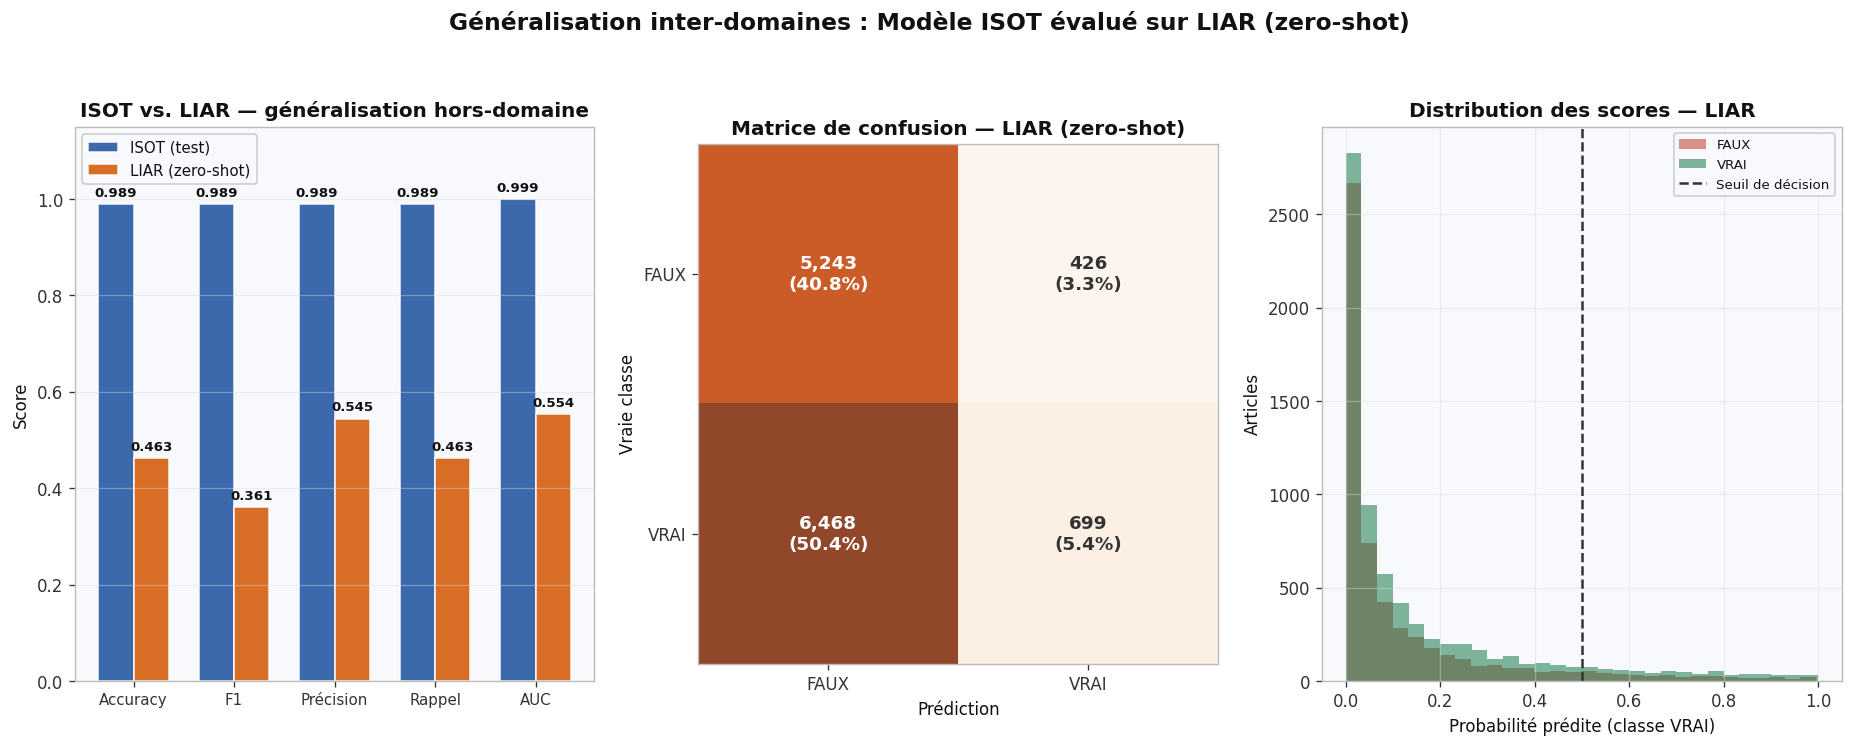


Note pour le mémire : ce panel constitue une contribution originale -- la plupart des travaux sur ISOT ne testent jamais la généralisation hors-domaine. Discuter ce résultat (même si F1 chute) renforce la rigueur scientifique du mémire plutôtpas de l'affaiblir.


In [ ]:
# CELL 19 Visualisation : generalisation ISOT -> LIAR
# ===========================================================================
fig, axes = plt.subplots(1, 3, figsize=(19, 6))
fig.patch.set_facecolor('white')

ax = axes[0]
metrics_names = ['accuracy', 'f1', 'precision', 'recall', 'roc_auc']
x = np.arange(len(metrics_names))
width = 0.35
bars1 = ax.bar(x - width/2, [isot_metrics[m] for m in metrics_names], width,
            label='ISOT (test)', color=COLORS['neutral'], alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + width/2, [liar_metrics[m] for m in metrics_names], width,
            label='LIAR (zero-shot)', color=COLORS['accent'], alpha=0.85, edgecolor='white')
for bars in (bars1, bars2):
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(['Accuracy','F1','Précision','Rappel','AUC'], fontsize=9)
ax.set_ylim(0, 1.15); ax.set_ylabel('Score')
ax.set_title('ISOT vs. LIAR — généralisation hors-domaine', fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.4)

ax = axes[1]
cm_liar = confusion_matrix(y_liar, y_liar_pred)
im = ax.imshow(cm_liar, cmap='Oranges', alpha=0.85)
for i in range(2):
    for j in range(2):
        pct = cm_liar[i,j] / cm_liar.sum() * 100
        ax.text(j, i, f'{cm_liar[i,j]:,}\n({pct:.1f}%)', ha='center', va='center',
                fontsize=11, fontweight='bold',
                color='white' if cm_liar[i,j] > cm_liar.max()/2 else '#333333')
ax.set_xticks([0,1]); ax.set_xticklabels(['FAUX','VRAI']); ax.set_yticks([0,1]); ax.set_yticklabels(['FAUX','VRAI'])
ax.set_xlabel('Prédiction'); ax.set_ylabel('Vraie classe')
ax.set_title('Matrice de confusion — LIAR (zero-shot)', fontsize=12, fontweight='bold')

ax = axes[2]
for lbl, col, nm in [(0, COLORS['fake'], 'FAUX'), (1, COLORS['real'], 'VRAI')]:
    mask = y_liar == lbl
    ax.hist(y_liar_prob[mask], bins=30, alpha=0.55, color=col, label=nm)
ax.axvline(0.5, color='#333333', ls='--', lw=1.5, label='Seuil de décision')
ax.set_xlabel('Probabilité prédite (classe VRAI)'); ax.set_ylabel('Articles')
ax.set_title('Distribution des scores — LIAR', fontsize=12, fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.4)

fig.suptitle("Généralisation inter-domaines : Modèle ISOT évalué sur LIAR (zero-shot)",
            fontsize=14, fontweight='bold', y=1.04)
save_fig('08_generalisation_liar.png'); plt.show()



In [243]:
# # CELL 20 Robustesse aux articles traduits (FR/ES -> EN)
# # ===========================================================================

# try:
#     from deep_translator import GoogleTranslator
# except ImportError:
#     import subprocess, sys
#     subprocess.run([sys.executable, '-m', 'pip', 'install', 'deep-translator',
#                     '--quiet', '--break-system-packages'], check=False)
#     from deep_translator import GoogleTranslator

# def translate_to_en(text, source_lang):
#     """Traduit un texte vers l'anglais avec gestion des textes longs.
#     Google Translate (gratuit) limite à ~5000 caractères par requête ;
#     on découpe par phrase si nécessaire."""
#     if len(text) <= 4500:
#         return GoogleTranslator(source=source_lang, target='en').translate(text)
#     # Découpage par phrases pour les textes longs
#     sentences = re.split(r'(?<=[.!?])\s+', text)
#     chunks, current = [], ''
#     for s in sentences:
#         if len(current) + len(s) < 4500:
#             current += ' ' + s
#         else:
#             chunks.append(current); current = s
#     if current:
#         chunks.append(current)
#     translated = [GoogleTranslator(source=source_lang, target='en').translate(c) for c in chunks]
#     return ' '.join(translated)

# def predict_article(text, label_hint=None):
#     """Applique le pipeline ISOT complet (clean -> vectorizer -> final_model)
#     sur un texte déjà en anglais, retourne la prédiction et la probabilité."""
#     cleaned = clean(text)
#     vec     = vectorizer.transform([cleaned])
#     pred    = final_model.predict(vec)[0]
#     prob    = final_model.predict_proba(vec)[0, 1]
#     return {'pred': pred, 'pred_label': 'VRAI' if pred==1 else 'FAUX','prob_real': prob}

In [244]:
# # CELL 21 — Test sur des articles FR/ES (exemples à remplacer par vos propres textes)
# # ===========================================================================
# test_articles = [
#     {
#         'lang': 'fr',
#         'true_label': 'VRAI',
#         'text': (
#             "Le conseil municipal a voté mardi soir le budget 2026 de la "
#             "commune. Le maire a précisé que les investissements porteront "
#             "principalement sur la rénovation des écoles et l'amélioration "
#             "des transports publics. Le vote s'est tenu à la majorité, avec "
#             "vingt-deux voix favorables et huit abstentions."
#         ),
#     },
#     {
#         'lang': 'fr',
#         'true_label': 'FAUX',
#         'text': (
#             "Des sources anonymes affirment que le gouvernement prévoit "
#             "secrètement de remplacer toute la monnaie nationale dès le mois "
#             "prochain, sans aucune annonce officielle. Aucune institution "
#             "financière n'a confirmé cette rumeur qui circule depuis "
#             "plusieurs jours sur les réseaux sociaux."
#         ),
#     },
#     {
#         'lang': 'es',
#         'true_label': 'VRAI',
#         'text': (
#             "El ministerio de salud confirmó este lunes que la campaña de "
#             "vacunación contra la gripe estacional comenzará la próxima "
#             "semana en los centros de salud pública. Las autoridades "
#             "recomiendan a las personas mayores de 65 años y a los grupos "
#             "de riesgo acudir a los centros más cercanos."
#         ),
#     },
#     {
#         'lang': 'es',
#         'true_label': 'FAUX',
#         'text': (
#             "Según publicaciones no verificadas en redes sociales, una "
#             "empresa habría descubierto una cura milagrosa para todas las "
#             "enfermedades, pero las autoridades sanitarias la estarían "
#             "ocultando deliberadamente al público. Ningún organismo "
#             "científico reconocido ha respaldado esta afirmación."
#         ),
#     },
# ]

# print(f"{len(test_articles)} articles de test (2 FR, 2 ES) -- traduction et prédiction...\n")

# results_translation = []
# for i, art in enumerate(test_articles):
#     print(f"--- Article {i+1} ({art['lang'].upper()}, vrai label : {art['true_label']}) ---")
#     translated = translate_to_en(art['text'], source_lang=art['lang'])
#     res = predict_article(translated, label_hint=art['true_label'])
#     res['lang'] = art['lang']
#     res['original_text'] = art['text']
#     res['translated_text'] = translated
#     results_translation.append(res)

#     correct = (res['pred_label'] == art['true_label'])
#     print(f"  Traduit (EN) : {translated[:120]}...")
#     print(f"  Prédiction : {res['pred_label']}  (P(VRAI)={res['prob_real']:.3f})  "
#         f"{'✓ correct' if correct else '✗ incorrect'}")
#     print()

# # ── Comparaison avec les mêmes articles écrits nativement en anglais ──
# # (paraphrase sémantiquement équivalente, rédigée directement en EN,
# # pour isoler l'effet de la traduction de l'effet du contenu)
# native_en_equivalents = [
#     "The city council voted Tuesday evening on the 2026 municipal budget. "
#     "The mayor said investments will focus mainly on school renovations "
#     "and public transport improvements. The vote passed with a majority, "
#     "twenty-two votes in favor and eight abstentions.",
#     "Anonymous sources claim the government is secretly planning to "
#     "replace the entire national currency next month, without any "
#     "official announcement. No financial institution has confirmed this "
#     "rumor, which has been circulating on social media for several days.",
#     "The health ministry confirmed Monday that the seasonal flu "
#     "vaccination campaign will begin next week at public health centers. "
#     "Authorities recommend that people over 65 and at-risk groups visit "
#     "their nearest center.",
#     "According to unverified social media posts, a company allegedly "
#     "discovered a miracle cure for all diseases, but health authorities "
#     "are supposedly deliberately hiding it from the public. No recognized "
#     "scientific organization has supported this claim.",
# ]

# print(f"\n{'='*70}")
# print("COMPARAISON : même contenu, rédigé nativement en anglais (sans traduction)")
# print(f"{'='*70}\n")
# results_native = []
# for i, (text, art) in enumerate(zip(native_en_equivalents, test_articles)):
#     res = predict_article(text, label_hint=art['true_label'])
#     results_native.append(res)
#     correct = (res['pred_label'] == art['true_label'])
#     print(f"Article {i+1} natif EN (vrai label : {art['true_label']}) : "
#           f"{res['pred_label']}  (P(VRAI)={res['prob_real']:.3f})  "
#           f"{'✓' if correct else '✗'}")


In [245]:
# # CELL 22 — Visualisation : translatoon impact
# # ===========================================================================
# fig, axes = plt.subplots(1, 3, figsize=(19, 6))
# fig.patch.set_facecolor('white')

# labels_short = [f"{r['lang'].upper()}{i+1}" for i, r in enumerate(results_translation)]

# # ── Panel 1 : P(VRAI) traduit vs natif, par article ──
# ax = axes[0]
# x = np.arange(len(results_translation))
# width = 0.35
# probs_trad   = [r['prob_real'] for r in results_translation]
# probs_native = [r['prob_real'] for r in results_native]
# bars1 = ax.bar(x - width/2, probs_trad,   width, label='Traduit (FR/ES->EN)',
#             color=COLORS['accent'], alpha=0.85, edgecolor='white')
# bars2 = ax.bar(x + width/2, probs_native, width, label='Natif EN (même contenu)',
#             color=COLORS['neutral'], alpha=0.85, edgecolor='white')
# ax.axhline(0.5, color='#333333', ls='--', lw=1.2, label='Seuil de décision')
# for bars in (bars1, bars2):
#     for bar in bars:
#         ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
#                 f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
# ax.set_xticks(x); ax.set_xticklabels(labels_short)
# ax.set_ylim(0, 1.1); ax.set_ylabel('P(VRAI) prédite')
# ax.set_title("Effet de la traduction sur la probabilité prédite", fontsize=12, fontweight='bold')
# ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.4)

# # ── Panel 2 : écart traduit - natif par article (le signal clé) ──
# ax = axes[1]
# deltas = [t - n for t, n in zip(probs_trad, probs_native)]
# colors_delta = [COLORS['fake'] if d < 0 else COLORS['real'] for d in deltas]
# bars = ax.barh(labels_short, deltas, color=colors_delta, alpha=0.85, edgecolor='white')
# ax.axvline(0, color='#333333', lw=1.2)
# for bar, d in zip(bars, deltas):
#     ax.text(d + (0.01 if d>=0 else -0.01), bar.get_y()+bar.get_height()/2,
#             f'{d:+.3f}', va='center', ha='left' if d>=0 else 'right', fontsize=9, fontweight='bold')
# ax.set_xlabel('Δ P(VRAI) = traduit - natif')
# ax.set_title("Pénalité de traduction par article\n(négatif = la traduction pousse vers FAUX)",
#              fontsize=11, fontweight='bold')
# ax.grid(axis='x', alpha=0.4)

# # ── Panel 3 : taux de classification FAUX, traduit vs natif (agrégé) ──
# ax = axes[2]
# pct_fake_trad   = sum(1 for r in results_translation if r['pred_label']=='FAUX') / len(results_translation) * 100
# pct_fake_native = sum(1 for r in results_native      if r['pred_label']=='FAUX') / len(results_native) * 100
# bars = ax.bar(['Traduit\n(FR/ES->EN)', 'Natif EN\n(même contenu)'],
#               [pct_fake_trad, pct_fake_native],
#               color=[COLORS['accent'], COLORS['neutral']], alpha=0.85,
#               edgecolor='white', width=0.5)
# for bar, v in zip(bars, [pct_fake_trad, pct_fake_native]):
#     ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1.5,
#             f'{v:.0f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
# ax.set_ylabel('% classés FAUX'); ax.set_ylim(0, 110)
# ax.set_title("Taux de classification FAUX\n(agrégé sur les 4 articles)", fontsize=11, fontweight='bold')
# ax.grid(axis='y', alpha=0.4)

# fig.suptitle("BIAIS DE TRADUCTION : LES ARTICLES TRADUITS SONT-ILS SUR-CLASSÉS COMME FAUX ?",
#              fontsize=14, fontweight='bold', y=1.04)
# save_fig('09_biais_traduction.png'); plt.show()

# print(f"\nRésumé : {pct_fake_trad:.0f}% des articles traduits classés FAUX, "
#     f"contre {pct_fake_native:.0f}% pour le même contenu rédigé nativement en anglais.")
# if pct_fake_trad > pct_fake_native:
#     print("-> Le résultat est cohérent avec l'hypothèse d'un biais de traduction : "
#         "le modèle associe des artefacts stylistiques de traduction (tournures "
#         "calquées, structure syntaxique source) à la classe FAUX, probablement "
#         "parce que les articles FAUX d'ISOT contiennent eux-mêmes une prose moins "
#         "soignée que les dépêches Reuters professionnelles de la classe VRAI.")
# else:
#     print("-> Sur ces exemples, pas de biais de traduction marqué -- "
#         "à confirmer avec un échantillon plus large d'articles réels.")

# print("\nLimite méthodologique à mentionner dans le mémoire : seulement 4 articles "
#     "testés ici à titre d'illustration. Pour une conclusion statistiquement "
#     "robuste, reproduire ce test sur un échantillon plus large (50-100 articles "
#     "FR/ES traduits, par exemple via Wikinews CC-BY ou un corpus académique "
#     "multilingue) et reporter un intervalle de confiance sur le delta observé.")
